In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

INPUT_DIR = Path('input')

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')
reviews = pd.read_csv(INPUT_DIR / 'reviews.csv', parse_dates=['review_date'])

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year'] = orders_d['order_date'].dt.year

sales_lines = (
    order_items
    .merge(orders_d[['order_id', 'order_date', 'year']], on='order_id', how='inner')
    .merge(
        products[['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']],
        on='product_id',
        how='left'
    )
)
sales_lines['year'] = sales_lines['order_date'].dt.year

review_base = reviews.merge(
    products[['product_id', 'product_name', 'category', 'segment']],
    on='product_id',
    how='left'
)
review_base['year'] = review_base['review_date'].dt.year


def safe_pct_change(new_value, old_value):
    if pd.isna(old_value) or old_value == 0:
        return np.nan
    return (new_value - old_value) / old_value * 100


def compare_start_end(yearly_df, group_col, metric_col, start_year=2012, end_year=2022, aggfunc='sum'):
    pivot = yearly_df.pivot_table(index=group_col, columns='year', values=metric_col, aggfunc=aggfunc, fill_value=0)
    start_series = pivot[start_year] if start_year in pivot.columns else pd.Series(np.nan, index=pivot.index)
    end_series = pivot[end_year] if end_year in pivot.columns else pd.Series(np.nan, index=pivot.index)

    out = pd.DataFrame({
        group_col: pivot.index,
        f'{metric_col}_{start_year}': start_series.values,
        f'{metric_col}_{end_year}': end_series.values,
    })
    out['abs_change'] = out[f'{metric_col}_{end_year}'] - out[f'{metric_col}_{start_year}']
    out['pct_change'] = np.where(
        out[f'{metric_col}_{start_year}'] > 0,
        out['abs_change'] / out[f'{metric_col}_{start_year}'] * 100,
        np.nan,
    )
    return out.sort_values('pct_change', ascending=True)


print('Loaded orders:', len(orders))
print('Delivered orders:', len(orders_d))
print('Order items:', len(order_items))
print('Products:', len(products))
print('Reviews:', len(reviews))
print('Year range:', int(orders_d['year'].min()), '->', int(orders_d['year'].max()))

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\1888023141.py:14: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')


Loaded orders: 646945
Delivered orders: 516716
Order items: 714669
Products: 2412
Reviews: 113551
Year range: 2012 -> 2022



CATEGORY VOLUME CHANGE 2012 -> 2022
  category  units_2012  units_2022  abs_change  pct_change
   Outdoor       69709       30027      -39682      -56.93
Streetwear       56555       82290       25735       45.50
      GenZ        4649       10669        6020      129.49
    Casual        2254        8447        6193      274.76

SEGMENT VOLUME CHANGE 2012 -> 2022
    segment  units_2012  units_2022  abs_change  pct_change
 Activewear       63257       24141      -39116      -61.84
   Everyday       30191       26678       -3513      -11.64
    Premium        6452        6620         168        2.60
   Standard        2093        2935         842       40.23
Performance       10735       18304        7569       70.51
     Trendy        4649       10669        6020      129.49
   Balanced       13536       34373       20837      153.94
All-weather        2254        7713        5459      242.19

Worst declining categories:
  category  units_2012  units_2022  abs_change  pct_change
   O

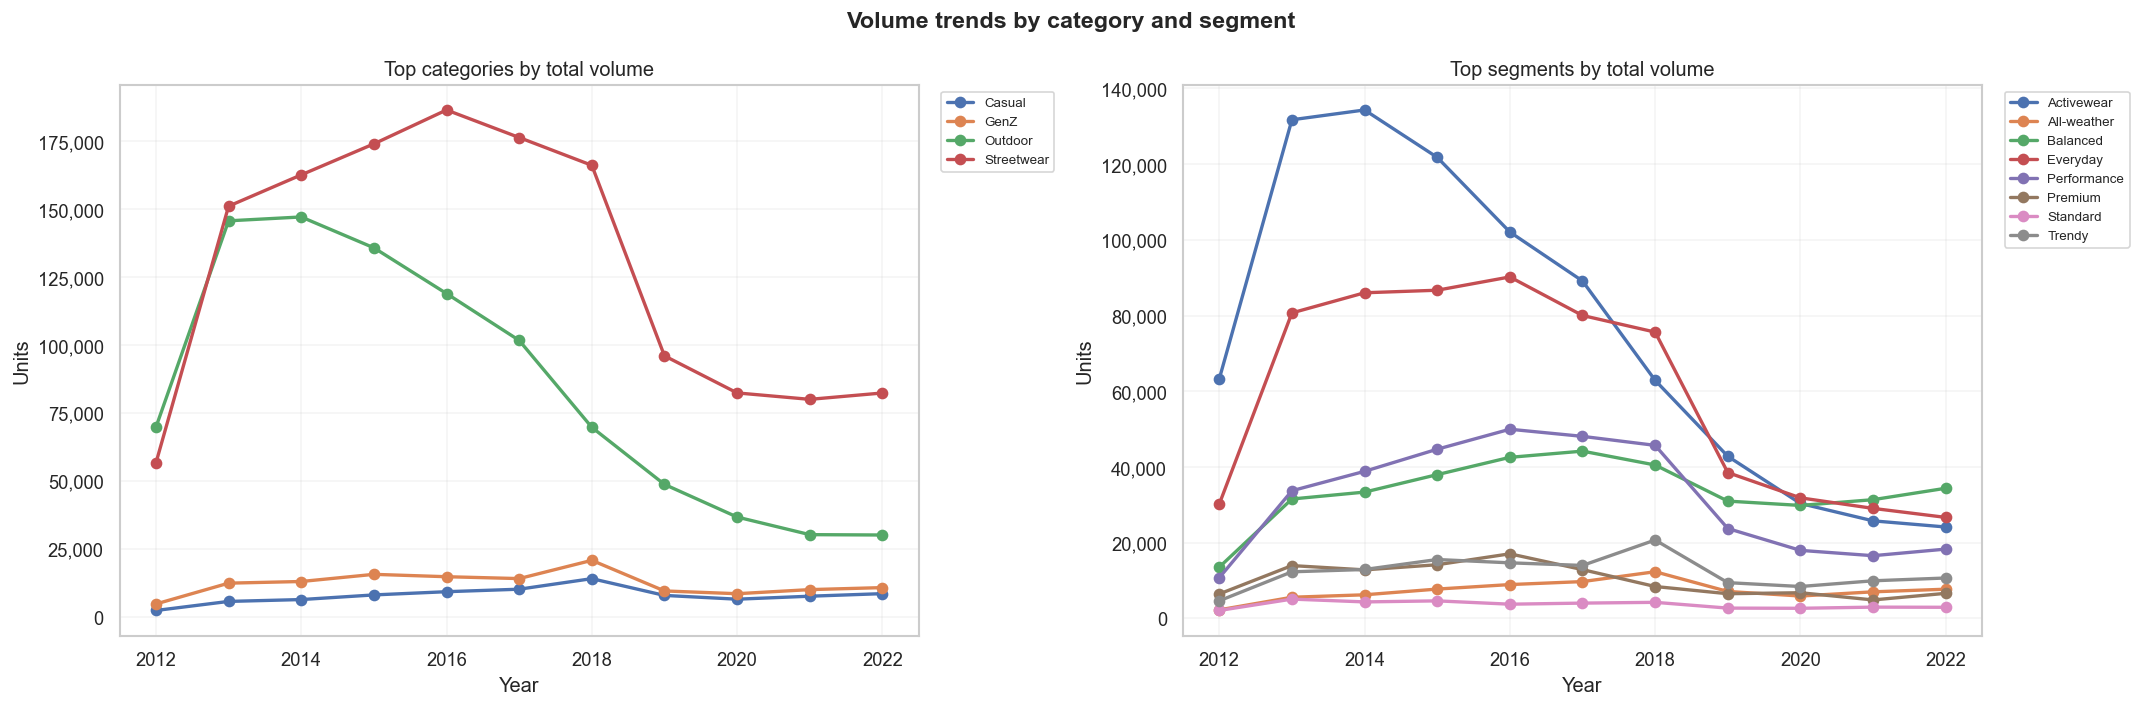

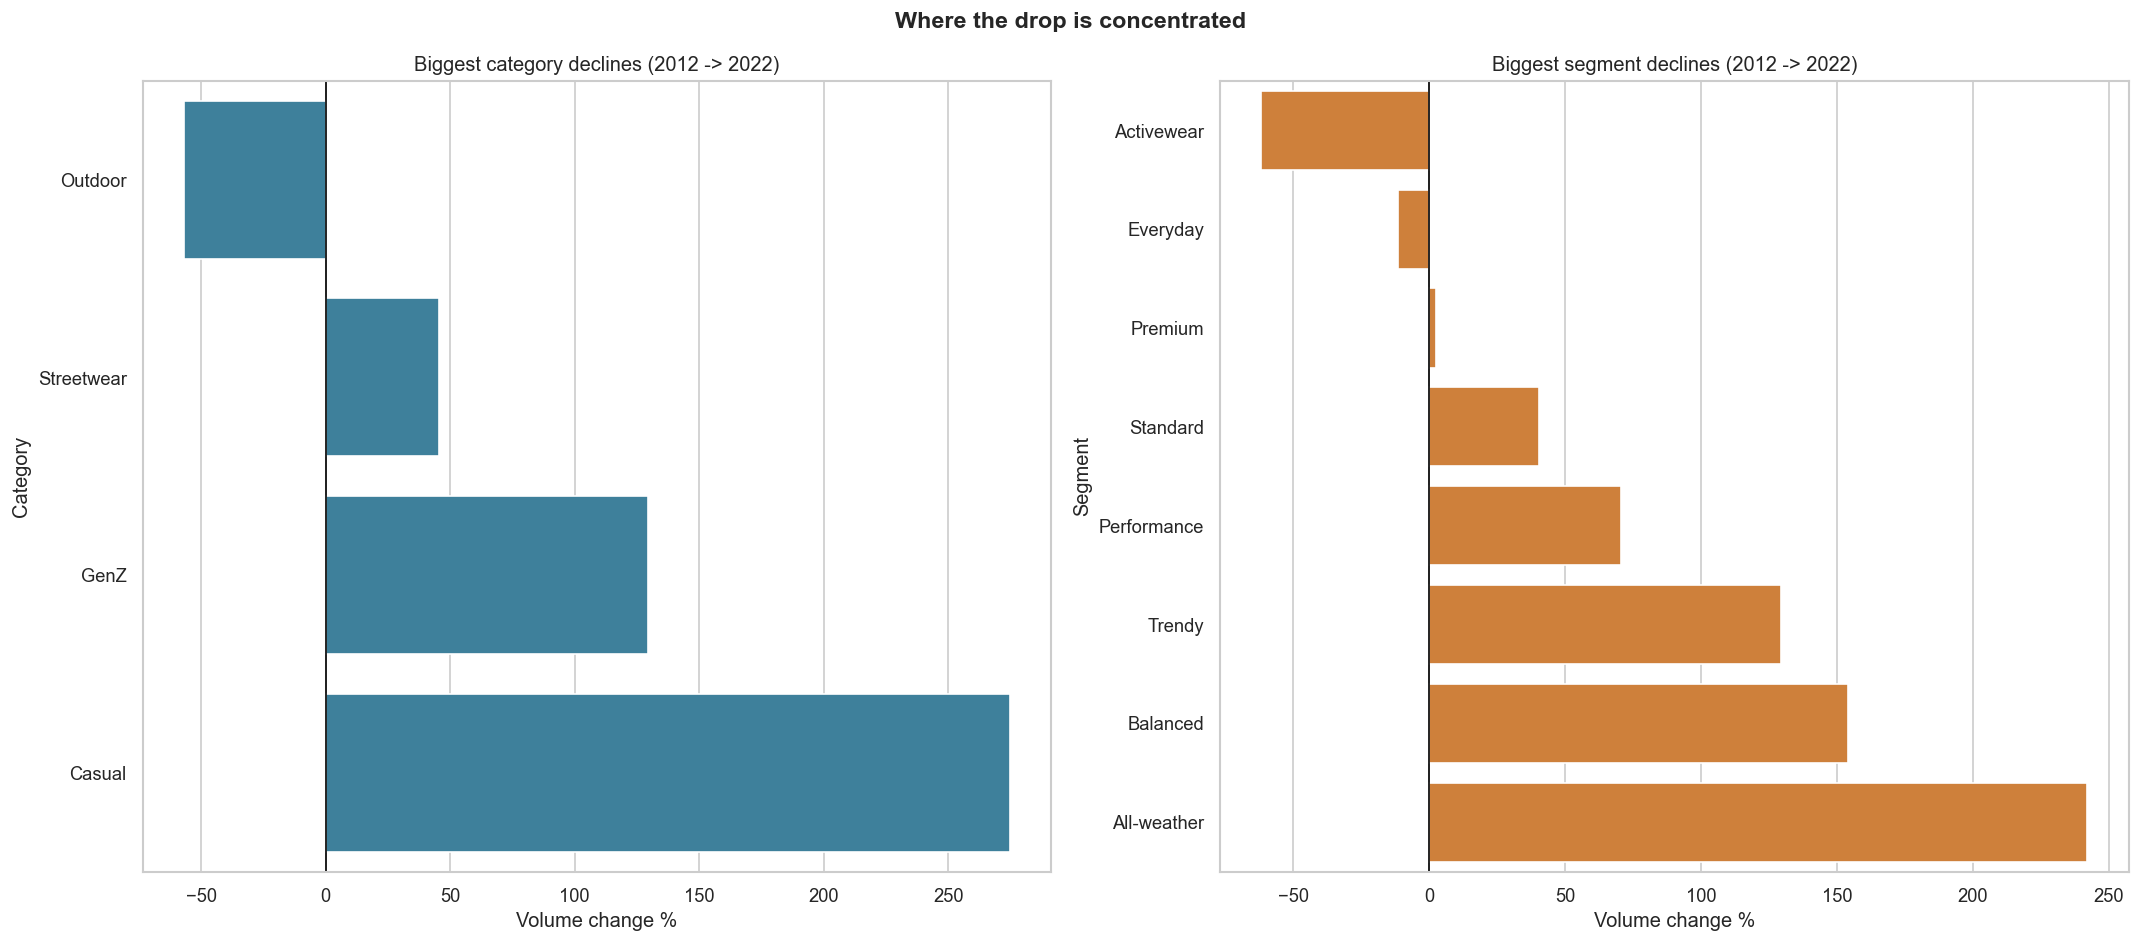

In [22]:
# ---------- 1) DESCRIPTIVE: volume by category and segment ----------
cat_year = (
    sales_lines.groupby(['year', 'category'], as_index=False)
    .agg(
        units=('quantity', 'sum'),
        orders=('order_id', 'nunique'),
        products=('product_id', 'nunique')
    )
)
seg_year = (
    sales_lines.groupby(['year', 'segment'], as_index=False)
    .agg(
        units=('quantity', 'sum'),
        orders=('order_id', 'nunique'),
        products=('product_id', 'nunique')
    )
)

cat_compare = compare_start_end(cat_year, 'category', 'units', 2012, 2022)
seg_compare = compare_start_end(seg_year, 'segment', 'units', 2012, 2022)

print('\n' + '=' * 90)
print('CATEGORY VOLUME CHANGE 2012 -> 2022')
print('=' * 90)
print(cat_compare[['category', 'units_2012', 'units_2022', 'abs_change', 'pct_change']].round(2).to_string(index=False))

print('\n' + '=' * 90)
print('SEGMENT VOLUME CHANGE 2012 -> 2022')
print('=' * 90)
print(seg_compare[['segment', 'units_2012', 'units_2022', 'abs_change', 'pct_change']].round(2).to_string(index=False))

print('\nWorst declining categories:')
print(cat_compare[['category', 'units_2012', 'units_2022', 'abs_change', 'pct_change']].head(10).round(2).to_string(index=False))

print('\nWorst declining segments:')
print(seg_compare[['segment', 'units_2012', 'units_2022', 'abs_change', 'pct_change']].head(10).round(2).to_string(index=False))

# Top category and segment trends over time
cat_top = cat_year.groupby('category')['units'].sum().sort_values(ascending=False).head(8).index
seg_top = seg_year.groupby('segment')['units'].sum().sort_values(ascending=False).head(8).index
cat_trend = cat_year[cat_year['category'].isin(cat_top)].pivot(index='year', columns='category', values='units').fillna(0)
seg_trend = seg_year[seg_year['segment'].isin(seg_top)].pivot(index='year', columns='segment', values='units').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
cat_trend.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('Top categories by total volume')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Units')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[0].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(True, alpha=0.2)

seg_trend.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Top segments by total volume')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Units')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(True, alpha=0.2)

fig.suptitle('Volume trends by category and segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
cat_decline = cat_compare.dropna(subset=['pct_change']).head(10).sort_values('pct_change')
seg_decline = seg_compare.dropna(subset=['pct_change']).head(10).sort_values('pct_change')

sns.barplot(data=cat_decline, x='pct_change', y='category', ax=axes[0], color='#2E86AB')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Biggest category declines (2012 -> 2022)')
axes[0].set_xlabel('Volume change %')
axes[0].set_ylabel('Category')

sns.barplot(data=seg_decline, x='pct_change', y='segment', ax=axes[1], color='#E67E22')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Biggest segment declines (2012 -> 2022)')
axes[1].set_xlabel('Volume change %')
axes[1].set_ylabel('Segment')

fig.suptitle('Where the drop is concentrated', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

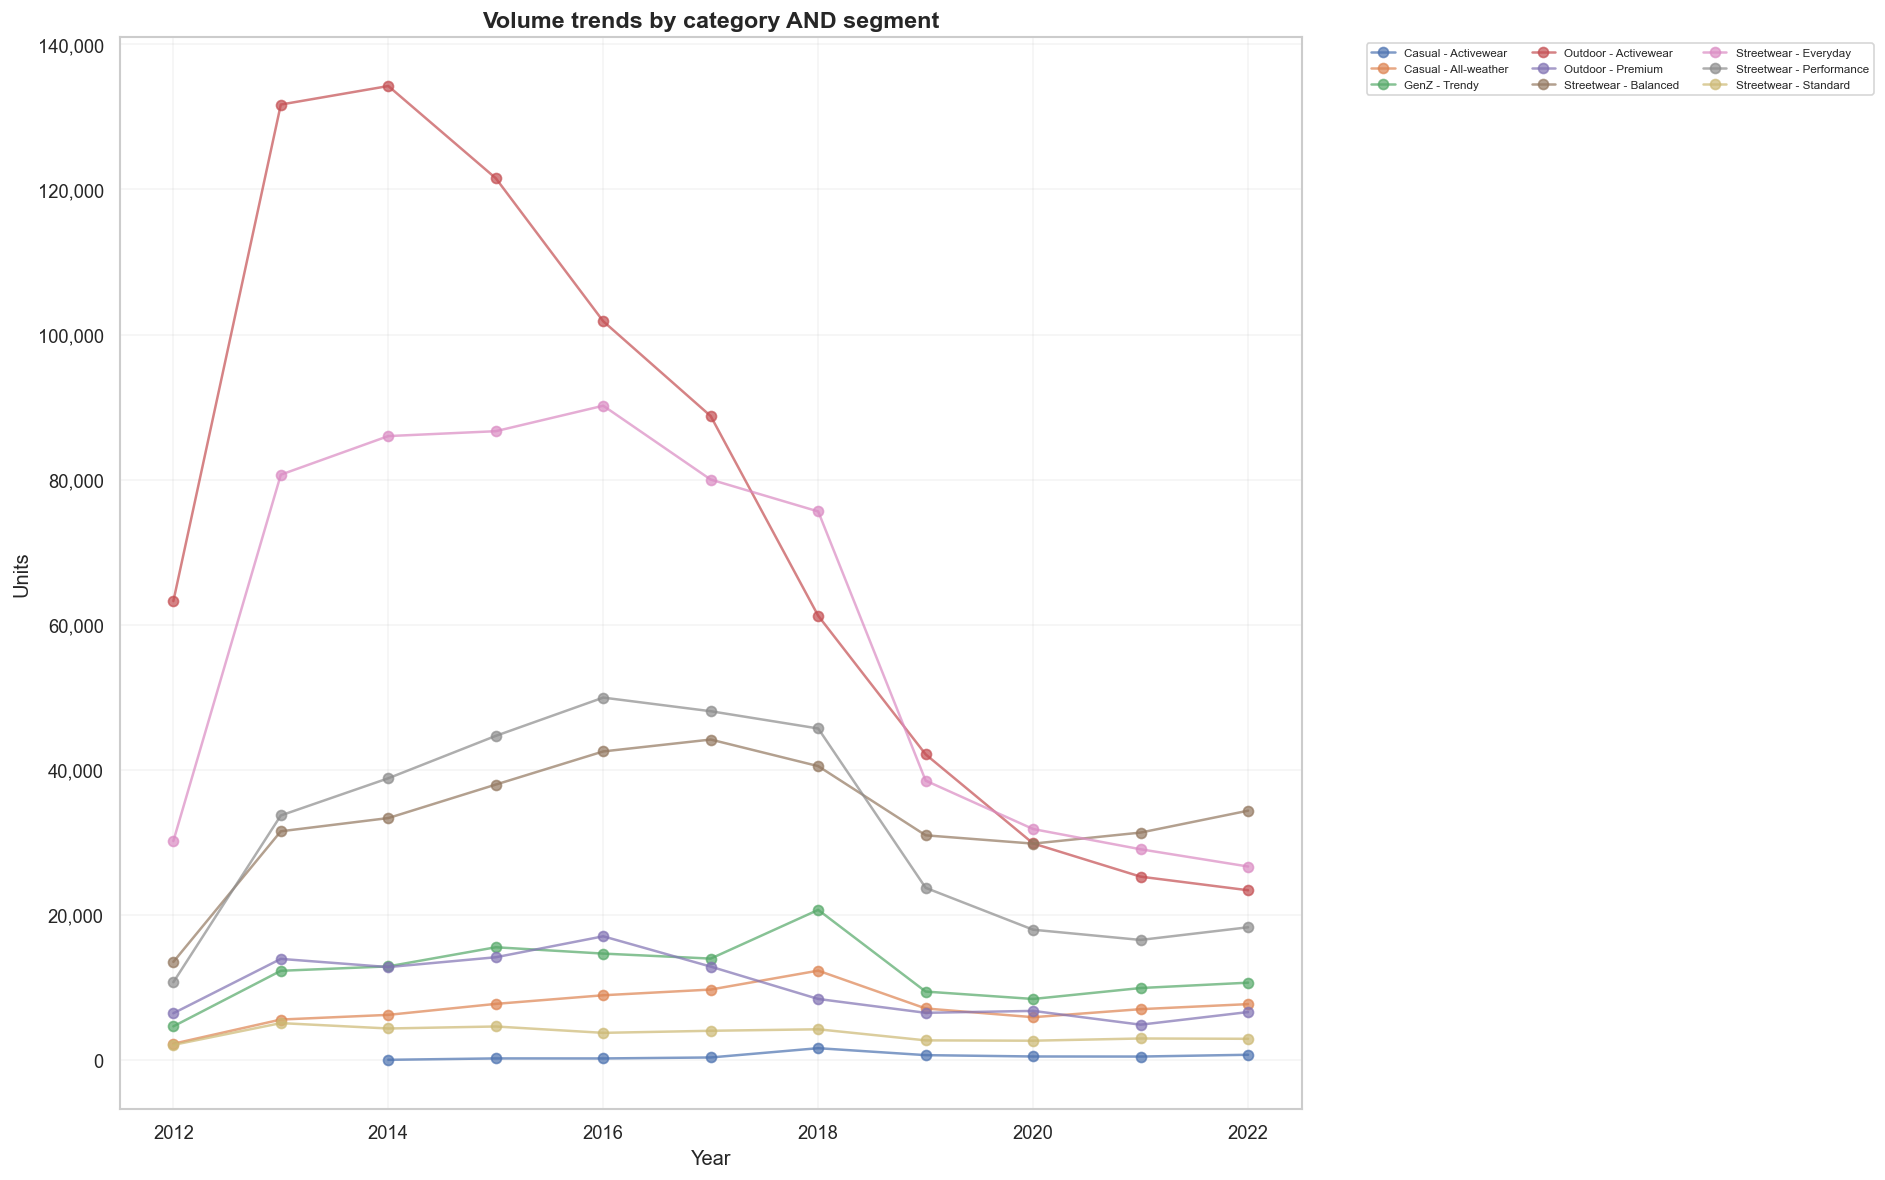

In [23]:
# Nested view: category with segment breakdown inside
cat_seg_year = (
    sales_lines.groupby(['year', 'category', 'segment'], as_index=False)
    .agg(units=('quantity', 'sum'))
)

fig, ax = plt.subplots(figsize=(16, 10))
for cat in sorted(cat_seg_year['category'].unique()):
    cat_data = cat_seg_year[cat_seg_year['category'] == cat]
    for seg in sorted(cat_data['segment'].unique()):
        seg_data = cat_data[cat_data['segment'] == seg].sort_values('year')
        ax.plot(seg_data['year'], seg_data['units'], marker='o', linewidth=1.5, alpha=0.7, label=f"{cat} - {seg}")

ax.set_title('Volume trends by category AND segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Units')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=7, ncol=3, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 3) ROOT CAUSE FRAMEWORK: H1 vs H2

**H1 (Appeal Weakening)**: Sản phẩm không còn hấp dẫn → check Sell-Through Rate + Rating Trend
**H2 (Operations Issue)**: Vấn đề mix hàng / vận hành → check Stock Paradox + Fill Rate

Chỉ số chính:
- **STR**: units_sold / units_received
- **Stock Paradox**: % top SKU stockout vs % bottom SKU overstock
- **Rating Trend**: avg_rating qua năm
- **Fill Rate**: của top 20% SKU

In [24]:
# CHỈ SỐ 1: SELL-THROUGH RATE
inventory = pd.read_csv(INPUT_DIR / 'inventory.csv', parse_dates=['snapshot_date'])

inventory_yearly = inventory.groupby(['year', 'segment'], as_index=False).agg({
    'units_received': 'sum',
    'units_sold': 'sum'
})
inventory_yearly['sell_through_rate'] = (
    inventory_yearly['units_sold'] / inventory_yearly['units_received']
).round(3)

print('\n' + '=' * 80)
print('CHỈ SỐ 1: SELL-THROUGH RATE (cao = bán nhanh)')
print('=' * 80)
str_pivot = inventory_yearly.pivot(index='segment', columns='year', values='sell_through_rate')
print(str_pivot.round(3).to_string())

print(f"\nSegments có trong inventory: {inventory_yearly['segment'].unique()}")

# Lấy top 2 declining segments từ seg_compare (từ cell 2)
top_declining = seg_compare.head(2)['segment'].tolist()
print(f"Top 2 declining segments (từ sales data): {top_declining}")

# Extract STR cho những segments này thay vì fixed 'Outdoor' & 'Streetwear'
for seg in top_declining:
    seg_str = inventory_yearly[inventory_yearly['segment'] == seg].sort_values('year')
    if not seg_str.empty:
        print(f"\n>>> {seg.upper()} STR trend:")
        print(seg_str[['year', 'sell_through_rate']].to_string(index=False))
        # Lưu để dùng ở conclusion
        if seg == top_declining[0]:
            seg1_name = seg
            seg1_str = seg_str
        elif seg == top_declining[1]:
            seg2_name = seg
            seg2_str = seg_str


CHỈ SỐ 1: SELL-THROUGH RATE (cao = bán nhanh)
year          2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022
segment                                                                                 
Activewear   0.847  0.847  0.848  0.849  0.852  0.852  0.856  0.865  0.873  0.876  0.877
All-weather  0.870  0.869  0.868  0.862  0.858  0.854  0.864  0.885  0.891  0.889  0.876
Balanced     0.852  0.852  0.850  0.850  0.845  0.849  0.853  0.848  0.851  0.852  0.854
Everyday     0.846  0.851  0.845  0.850  0.847  0.852  0.851  0.864  0.872  0.867  0.865
Performance  0.862  0.851  0.848  0.846  0.848  0.842  0.850  0.859  0.868  0.867  0.861
Premium      0.846  0.851  0.856  0.856  0.858  0.858  0.849  0.863  0.863  0.877  0.881
Standard     0.913  0.896  0.901  0.898  0.907  0.900  0.894  0.918  0.918  0.907  0.903
Trendy       0.857  0.857  0.855  0.864  0.862  0.856  0.856  0.878  0.887  0.878  0.881

Segments có trong inventory: ['Activewear' 'All-weather' 'Bala

In [25]:
# CHỈ SỐ 2: STOCK PARADOX

top_sku_by_sales = sales_lines.groupby('product_id')['quantity'].sum().sort_values(ascending=False)
top_20_pct_threshold = max(1, int(len(top_sku_by_sales) * 0.2))
top_sku_list = top_sku_by_sales.head(top_20_pct_threshold).index

inventory['sku_tier'] = inventory['product_id'].apply(
    lambda x: 'Top 20%' if x in top_sku_list else 'Bottom 80%'
)

stock_paradox = inventory.groupby(['year', 'segment', 'sku_tier'], as_index=False).agg({
    'stockout_flag': 'mean',
    'overstock_flag': 'mean',
    'fill_rate': 'mean'
}).round(3)

print('\n' + '=' * 80)
print('CHỈ SỐ 2: STOCK PARADOX (phần trăm SKU bị stockout vs overstock)')
print('=' * 80)
print(stock_paradox.to_string(index=False))


CHỈ SỐ 2: STOCK PARADOX (phần trăm SKU bị stockout vs overstock)
 year     segment   sku_tier  stockout_flag  overstock_flag  fill_rate
 2012  Activewear Bottom 80%          0.671           0.449      0.962
 2012  Activewear    Top 20%          0.657           0.519      0.948
 2012 All-weather Bottom 80%          0.623           0.491      0.966
 2012 All-weather    Top 20%          0.562           0.771      0.972
 2012    Balanced Bottom 80%          0.718           0.436      0.945
 2012    Balanced    Top 20%          0.717           0.655      0.914
 2012    Everyday Bottom 80%          0.681           0.619      0.946
 2012    Everyday    Top 20%          0.711           0.825      0.961
 2012 Performance Bottom 80%          0.695           0.541      0.965
 2012 Performance    Top 20%          0.663           0.857      0.966
 2012     Premium Bottom 80%          0.792           0.562      0.931
 2012     Premium    Top 20%          0.581           0.284      0.914
 2012    St

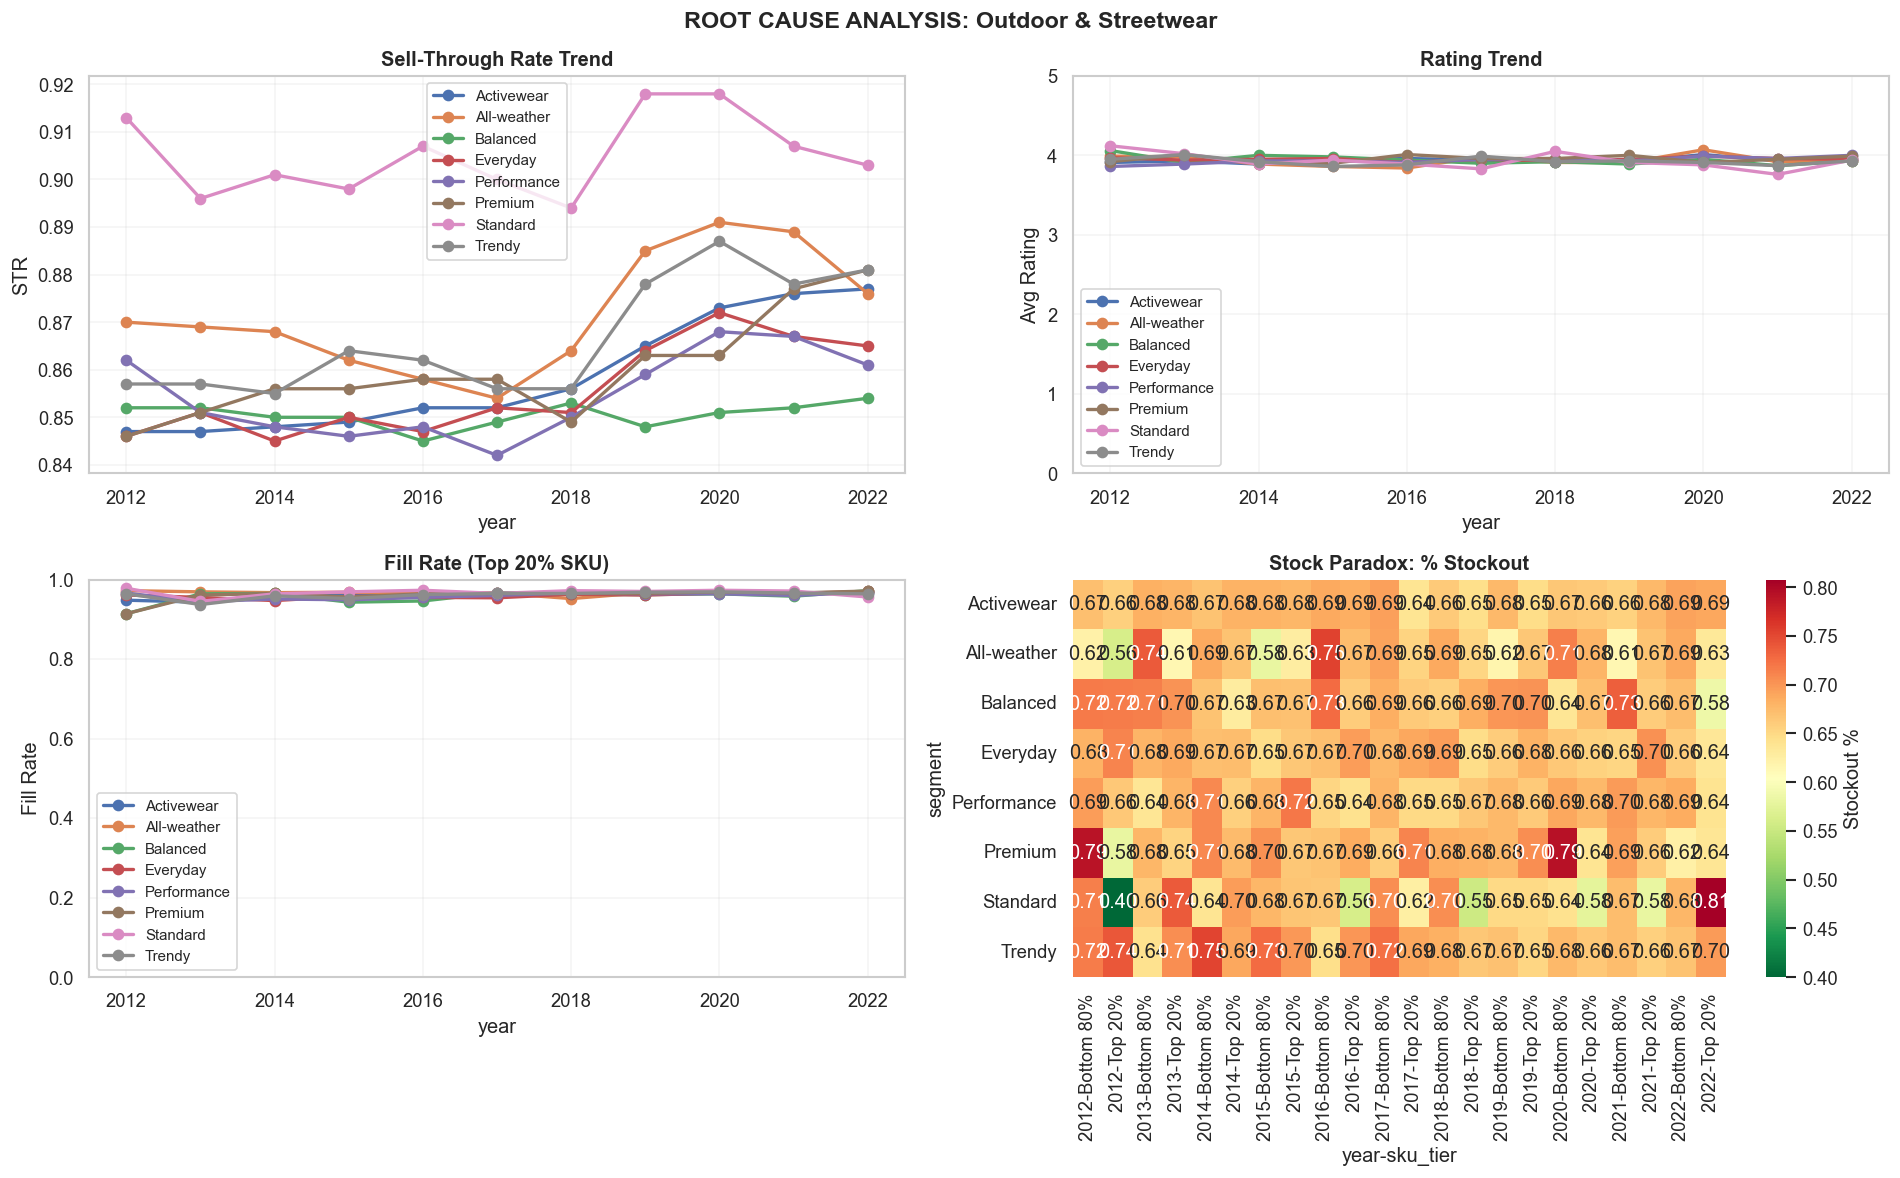

In [26]:
# CHỈ SỐ 3 & 4: RATING + VISUALIZATION
rating_seg_year = review_base.groupby(['year', 'segment'], as_index=False).agg({
    'rating': 'mean'
}).round(2)

fill_rate_top = inventory[inventory['sku_tier'] == 'Top 20%'].groupby(['year', 'segment'], as_index=False).agg({
    'fill_rate': 'mean'
}).round(3)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# STR Trend
str_seg_pivot = inventory_yearly.pivot(index='year', columns='segment', values='sell_through_rate')
str_seg_pivot.plot(ax=axes[0, 0], marker='o', linewidth=2)
axes[0, 0].set_title('Sell-Through Rate Trend', fontweight='bold')
axes[0, 0].set_ylabel('STR')
axes[0, 0].grid(True, alpha=0.2)
axes[0, 0].legend(fontsize=9)

# Rating Trend
rating_pivot = rating_seg_year.pivot(index='year', columns='segment', values='rating')
rating_pivot.plot(ax=axes[0, 1], marker='o', linewidth=2)
axes[0, 1].set_title('Rating Trend', fontweight='bold')
axes[0, 1].set_ylabel('Avg Rating')
axes[0, 1].set_ylim([0, 5])
axes[0, 1].grid(True, alpha=0.2)
axes[0, 1].legend(fontsize=9)

# Fill Rate
fill_pivot = fill_rate_top.pivot(index='year', columns='segment', values='fill_rate')
fill_pivot.plot(ax=axes[1, 0], marker='o', linewidth=2)
axes[1, 0].set_title('Fill Rate (Top 20% SKU)', fontweight='bold')
axes[1, 0].set_ylabel('Fill Rate')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.2)
axes[1, 0].legend(fontsize=9)

# Stock Paradox Heatmap
paradox_heatmap_data = stock_paradox.pivot_table(
    index='segment', 
    columns=['year', 'sku_tier'], 
    values='stockout_flag'
)
sns.heatmap(paradox_heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1, 1], cbar_kws={'label': 'Stockout %'})
axes[1, 1].set_title('Stock Paradox: % Stockout', fontweight='bold')

fig.suptitle('ROOT CAUSE ANALYSIS: Outdoor & Streetwear', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# DEBUG: kiểm tra các biến có tồn tại không
print("DEBUG INFO:")
try:
    print(f"seg1_name: {seg1_name}, seg1_str shape: {seg1_str.shape}")
    print(f"seg2_name: {seg2_name}, seg2_str shape: {seg2_str.shape}")
except NameError as e:
    print(f"Warning: {e}")
print(f"\nrating_seg_year shape: {rating_seg_year.shape}")
print(f"rating_seg_year segments: {rating_seg_year['segment'].unique()}")
print(f"\nfill_rate_top shape: {fill_rate_top.shape}")
print(f"fill_rate_top segments: {fill_rate_top['segment'].unique()}")


DEBUG INFO:
seg1_name: Activewear, seg1_str shape: (11, 5)
seg2_name: Everyday, seg2_str shape: (11, 5)

rating_seg_year shape: (88, 3)
rating_seg_year segments: ['Activewear' 'All-weather' 'Balanced' 'Everyday' 'Performance' 'Premium'
 'Standard' 'Trendy']

fill_rate_top shape: (88, 3)
fill_rate_top segments: ['Activewear' 'All-weather' 'Balanced' 'Everyday' 'Performance' 'Premium'
 'Standard' 'Trendy']


In [28]:
# KẾT LUẬN: H1 vs H2
print('\n' + '=' * 80)
print('KẾT LUẬN: H1 (appeal) vs H2 (vận hành)?')
print('=' * 80)

# Segment 1
print(f'\n>>> {seg1_name.upper()}: 2012 → 2022')
s1_str_12_vals = seg1_str[seg1_str['year'] == 2012]['sell_through_rate'].values
s1_str_22_vals = seg1_str[seg1_str['year'] == 2022]['sell_through_rate'].values
s1_rat_12_vals = rating_seg_year[(rating_seg_year['segment'] == seg1_name) & (rating_seg_year['year'] == 2012)]['rating'].values
s1_rat_22_vals = rating_seg_year[(rating_seg_year['segment'] == seg1_name) & (rating_seg_year['year'] == 2022)]['rating'].values
s1_fill_12_vals = fill_rate_top[(fill_rate_top['segment'] == seg1_name) & (fill_rate_top['year'] == 2012)]['fill_rate'].values
s1_fill_22_vals = fill_rate_top[(fill_rate_top['segment'] == seg1_name) & (fill_rate_top['year'] == 2022)]['fill_rate'].values

if len(s1_str_12_vals) > 0 and len(s1_str_22_vals) > 0:
    s1_str_12 = float(s1_str_12_vals[0])
    s1_str_22 = float(s1_str_22_vals[0])
    trend = '↓ H1' if s1_str_22 < s1_str_12 else '↑'
    print(f"   STR: {s1_str_12:.3f} → {s1_str_22:.3f} | {trend}")

if len(s1_rat_12_vals) > 0 and len(s1_rat_22_vals) > 0:
    s1_rat_12 = float(s1_rat_12_vals[0])
    s1_rat_22 = float(s1_rat_22_vals[0])
    trend = '↓ H1' if s1_rat_22 < s1_rat_12 else '↑'
    print(f"   Rating: {s1_rat_12:.2f} → {s1_rat_22:.2f} | {trend}")

if len(s1_fill_12_vals) > 0 and len(s1_fill_22_vals) > 0:
    s1_fill_12 = float(s1_fill_12_vals[0])
    s1_fill_22 = float(s1_fill_22_vals[0])
    trend = '↓ H2' if s1_fill_22 < s1_fill_12 else '↑'
    print(f"   Fill Rate: {s1_fill_12:.3f} → {s1_fill_22:.3f} | {trend}")

# Segment 2
print(f'\n>>> {seg2_name.upper()}: 2012 → 2022')
s2_str_12_vals = seg2_str[seg2_str['year'] == 2012]['sell_through_rate'].values
s2_str_22_vals = seg2_str[seg2_str['year'] == 2022]['sell_through_rate'].values
s2_rat_12_vals = rating_seg_year[(rating_seg_year['segment'] == seg2_name) & (rating_seg_year['year'] == 2012)]['rating'].values
s2_rat_22_vals = rating_seg_year[(rating_seg_year['segment'] == seg2_name) & (rating_seg_year['year'] == 2022)]['rating'].values
s2_fill_12_vals = fill_rate_top[(fill_rate_top['segment'] == seg2_name) & (fill_rate_top['year'] == 2012)]['fill_rate'].values
s2_fill_22_vals = fill_rate_top[(fill_rate_top['segment'] == seg2_name) & (fill_rate_top['year'] == 2022)]['fill_rate'].values

if len(s2_str_12_vals) > 0 and len(s2_str_22_vals) > 0:
    s2_str_12 = float(s2_str_12_vals[0])
    s2_str_22 = float(s2_str_22_vals[0])
    trend = '↓ H1' if s2_str_22 < s2_str_12 else '↑'
    print(f"   STR: {s2_str_12:.3f} → {s2_str_22:.3f} | {trend}")

if len(s2_rat_12_vals) > 0 and len(s2_rat_22_vals) > 0:
    s2_rat_12 = float(s2_rat_12_vals[0])
    s2_rat_22 = float(s2_rat_22_vals[0])
    trend = '↓ H1' if s2_rat_22 < s2_rat_12 else '↑'
    print(f"   Rating: {s2_rat_12:.2f} → {s2_rat_22:.2f} | {trend}")

if len(s2_fill_12_vals) > 0 and len(s2_fill_22_vals) > 0:
    s2_fill_12 = float(s2_fill_12_vals[0])
    s2_fill_22 = float(s2_fill_22_vals[0])
    trend = '↓ H2' if s2_fill_22 < s2_fill_12 else '↑'
    print(f"   Fill Rate: {s2_fill_12:.3f} → {s2_fill_22:.3f} | {trend}")


KẾT LUẬN: H1 (appeal) vs H2 (vận hành)?

>>> ACTIVEWEAR: 2012 → 2022
   STR: 0.847 → 0.877 | ↑
   Rating: 3.91 → 3.96 | ↑
   Fill Rate: 0.948 → 0.966 | ↑

>>> EVERYDAY: 2012 → 2022
   STR: 0.846 → 0.865 | ↑
   Rating: 3.97 → 3.95 | ↓ H1
   Fill Rate: 0.961 → 0.970 | ↑


In [29]:
# ============================================================
# ASSORTMENT DECAY ANALYSIS
# H3: Doanh nghiệp tự thu hẹp danh mục Outdoor/Streetwear?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

INPUT_DIR = Path('input')

order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year'] = orders_d['order_date'].dt.year

# Base table: mỗi dòng = 1 SKU bán trong 1 đơn delivered, có year
lines = (
    order_items
    .merge(orders_d[['order_id', 'year']], on='order_id', how='inner')
    .merge(products[['product_id', 'category', 'segment', 'price', 'cogs']], on='product_id', how='left')
)
lines['gross_margin'] = (lines['price'] - lines['cogs']) / lines['price']

# ── Derive launch_year & last_year từ transaction history ──────────────────
sku_lifespan = (
    lines.groupby('product_id')
    .agg(launch_year=('year', 'min'), last_year=('year', 'max'))
    .reset_index()
)
sku_lifespan = sku_lifespan.merge(
    products[['product_id', 'category', 'segment', 'price', 'cogs']], on='product_id'
)
sku_lifespan['gross_margin_pct'] = (
    (sku_lifespan['price'] - sku_lifespan['cogs']) / sku_lifespan['price'] * 100
)

ANALYSIS_YEARS = sorted(lines['year'].unique())
MAX_YEAR       = max(ANALYSIS_YEARS)

print(f"Year range: {min(ANALYSIS_YEARS)} → {MAX_YEAR}")
print(f"Total SKUs with transactions: {len(sku_lifespan)}")
print(f"\nSKUs per category:")
print(sku_lifespan['category'].value_counts().to_string())

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\1902712758.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')


Year range: 2012 → 2022
Total SKUs with transactions: 1575

SKUs per category:
category
Streetwear    867
Outdoor       485
Casual        112
GenZ          111


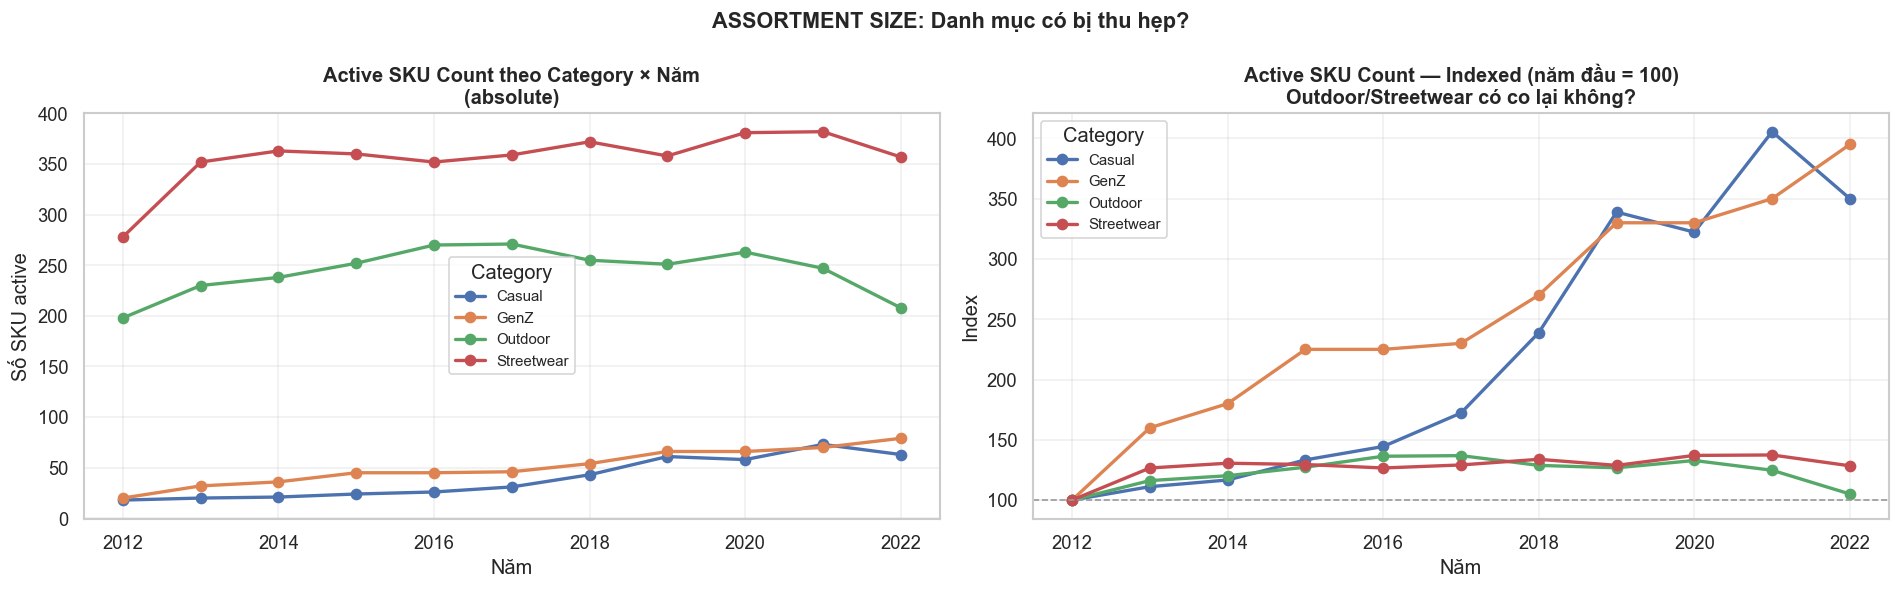

In [30]:
# ── CHART 1: Active SKU count per year per category ────────────────────────
# "Active" = SKU có ít nhất 1 đơn trong năm đó

active_sku_year = (
    lines.groupby(['year', 'category'])['product_id']
    .nunique()
    .reset_index(name='active_skus')
)

pivot_active = active_sku_year.pivot(index='year', columns='category', values='active_skus').fillna(0)

# Normalize về index (year đầu tiên = 100) để dễ so sánh trend
pivot_idx = pivot_active.div(pivot_active.iloc[0]) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute
pivot_active.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('Active SKU Count theo Category × Năm\n(absolute)', fontweight='bold')
axes[0].set_ylabel('Số SKU active')
axes[0].set_xlabel('Năm')
axes[0].legend(title='Category', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

# Indexed
pivot_idx.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].axhline(100, color='#999', linestyle='--', linewidth=1)
axes[1].set_title('Active SKU Count — Indexed (năm đầu = 100)\nOutdoor/Streetwear có co lại không?', fontweight='bold')
axes[1].set_ylabel('Index')
axes[1].set_xlabel('Năm')
axes[1].legend(title='Category', fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('ASSORTMENT SIZE: Danh mục có bị thu hẹp?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

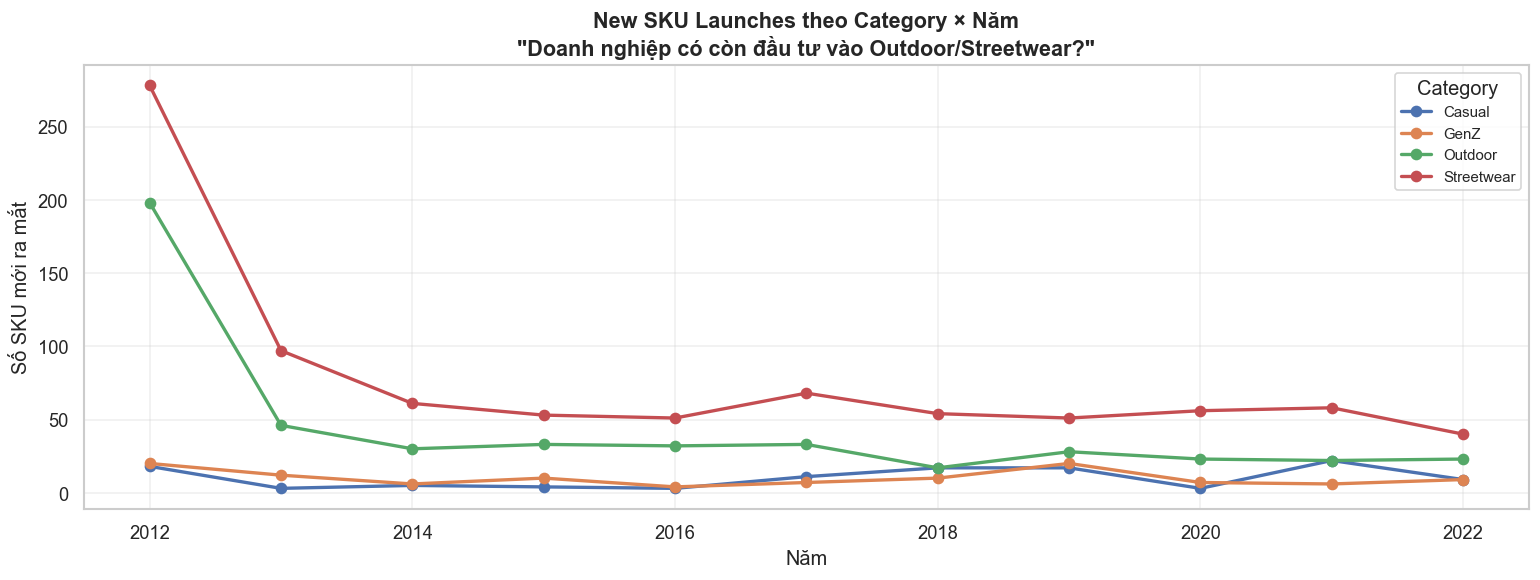


New SKU launches by category (tổng theo period):
category       Casual  GenZ  Outdoor  Streetwear
period                                          
P1: 2012–2018      61    69      389         662
P2: 2019–2022      51    42       96         205


In [31]:
# ── CHART 2: New SKU launches per year per category ────────────────────────
# "New" = SKU có launch_year = year đó

new_skus = (
    sku_lifespan.groupby(['launch_year', 'category'])['product_id']
    .nunique()
    .reset_index(name='new_skus')
    .rename(columns={'launch_year': 'year'})
)

pivot_new = new_skus.pivot(index='year', columns='category', values='new_skus').fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
pivot_new.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('New SKU Launches theo Category × Năm\n"Doanh nghiệp có còn đầu tư vào Outdoor/Streetwear?"',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Số SKU mới ra mắt')
ax.set_xlabel('Năm')
ax.legend(title='Category', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.tight_layout()
plt.show()

print('\nNew SKU launches by category (tổng theo period):')
new_skus['period'] = new_skus['year'].apply(lambda y: 'P1: 2012–2018' if y <= 2018 else 'P2: 2019–2022')
print(new_skus.groupby(['period', 'category'])['new_skus'].sum().unstack().fillna(0).round(0))

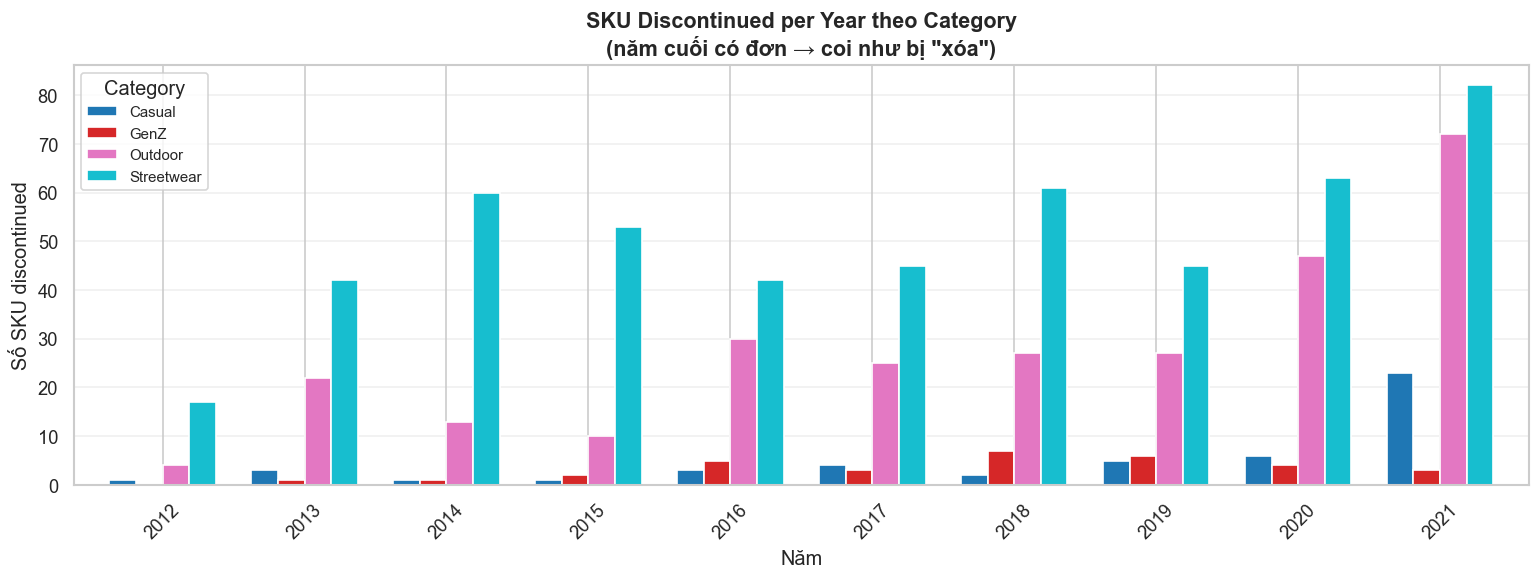

In [32]:
# ── CHART 3: SKU "churn" — bao nhiêu SKU bị discontinued mỗi năm ───────────
# "Discontinued" = last_year = y nhưng không có đơn ở y+1

# SKU còn sống ở year y = có đơn ở y VÀ (last_year > y hoặc y = MAX_YEAR)
discontinued = (
    sku_lifespan[sku_lifespan['last_year'] < MAX_YEAR]  # loại SKU còn active đến cuối
    .groupby(['last_year', 'category'])['product_id']
    .nunique()
    .reset_index(name='discontinued_skus')
    .rename(columns={'last_year': 'year'})
)

pivot_disc = discontinued.pivot(index='year', columns='category', values='discontinued_skus').fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
pivot_disc.plot(kind='bar', ax=ax, width=0.75, colormap='tab10')
ax.set_title('SKU Discontinued per Year theo Category\n(năm cuối có đơn → coi như bị "xóa")',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Số SKU discontinued')
ax.set_xlabel('Năm')
ax.legend(title='Category', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

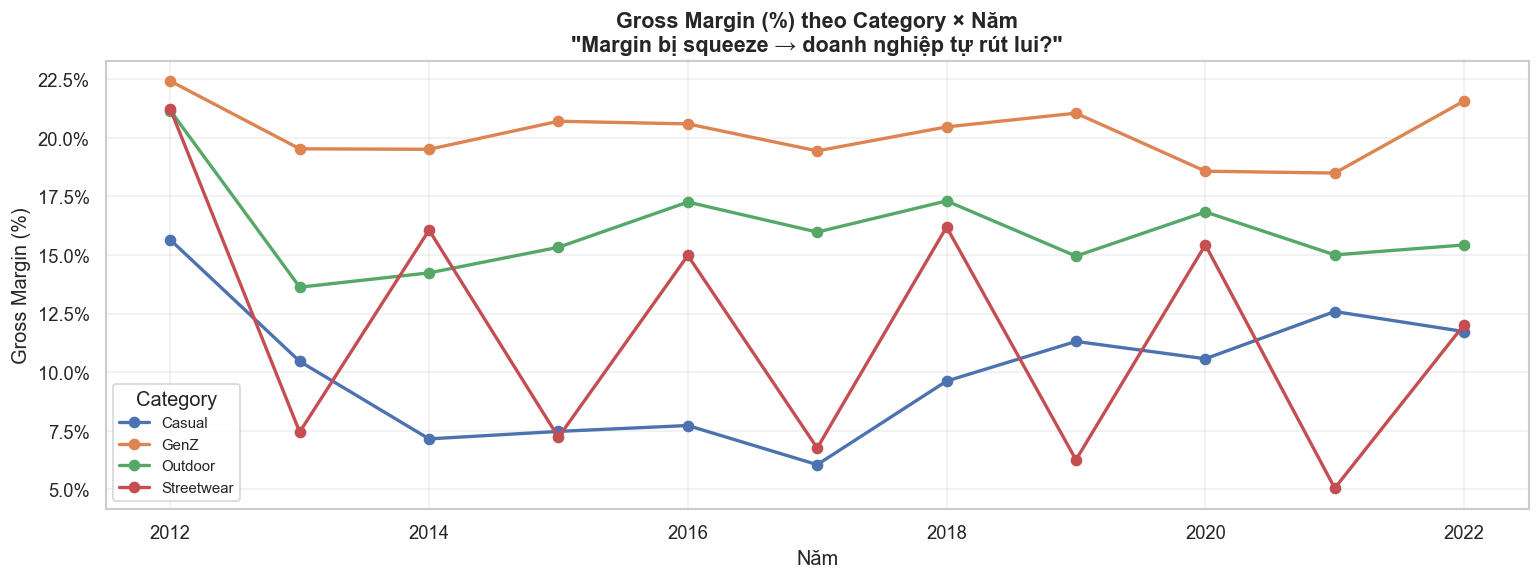


Gross Margin by category (avg across all years):
category
Casual        10.03
GenZ          20.22
Outdoor       16.10
Streetwear    11.70


In [33]:
# ── CHART 4: Gross Margin trend theo Category × Năm ────────────────────────
# Nếu margin bị squeeze → doanh nghiệp có lý do kinh tế để deprioritize

from matplotlib import lines


margin_year = (
    sales_lines
    .assign(gross_margin=lambda d: (d['unit_price'] - d['cogs']) / d['unit_price'].replace(0, np.nan))
    .groupby(['year', 'category'], as_index=False)
    .agg(avg_margin=('gross_margin', 'mean'))
)
margin_year['avg_margin_pct'] = margin_year['avg_margin'] * 100

pivot_margin = margin_year.pivot(index='year', columns='category', values='avg_margin_pct')

fig, ax = plt.subplots(figsize=(13, 5))
pivot_margin.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Gross Margin (%) theo Category × Năm\n"Margin bị squeeze → doanh nghiệp tự rút lui?"',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Gross Margin (%)')
ax.set_xlabel('Năm')
ax.legend(title='Category', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
plt.tight_layout()
plt.show()

print('\nGross Margin by category (avg across all years):')
print(margin_year.groupby('category')['avg_margin_pct'].mean().round(2).to_string())

In [34]:
# ── SUMMARY TABLE: H3 Verdict ──────────────────────────────────────────────

print('=' * 70)
print('H3 ASSORTMENT DECAY — SUMMARY')
print('=' * 70)

for cat in sorted(sku_lifespan['category'].unique()):
    sub = sku_lifespan[sku_lifespan['category'] == cat]
    act_p1 = active_sku_year[(active_sku_year['category'] == cat) & (active_sku_year['year'] <= 2018)]['active_skus'].mean()
    act_p2 = active_sku_year[(active_sku_year['category'] == cat) & (active_sku_year['year'] > 2018)]['active_skus'].mean()
    
    new_p1 = new_skus[(new_skus['category'] == cat) & (new_skus['year'] <= 2018)]['new_skus'].sum()
    new_p2 = new_skus[(new_skus['category'] == cat) & (new_skus['year'] > 2018)]['new_skus'].sum()
    
    m_p1 = margin_year[(margin_year['category'] == cat) & (margin_year['year'] <= 2018)]['avg_margin_pct'].mean()
    m_p2 = margin_year[(margin_year['category'] == cat) & (margin_year['year'] > 2018)]['avg_margin_pct'].mean()
    
    print(f'\n{cat}:')
    print(f'  Active SKUs  : P1 avg={act_p1:.0f}  →  P2 avg={act_p2:.0f}  ({"↓" if act_p2 < act_p1 else "↑"}{abs(act_p2-act_p1)/act_p1*100:.1f}%)')
    print(f'  New launches : P1={new_p1:.0f}  →  P2={new_p2:.0f}  ({"↓" if new_p2 < new_p1 else "↑"}{abs(new_p2-new_p1)/max(new_p1,1)*100:.1f}%)')
    print(f'  Gross margin : P1={m_p1:.1f}%  →  P2={m_p2:.1f}%  ({"↓" if m_p2 < m_p1 else "↑"}{abs(m_p2-m_p1):.1f}pp)')

print('\n\nKẾT LUẬN H3:')
print('Nếu Outdoor/Streetwear có 2/3 dấu hiệu sau → H3 được ủng hộ:')
print('  [1] Active SKUs giảm rõ ở P2 so với P1')
print('  [2] New launches P2 thấp hơn hẳn P1')
print('  [3] Gross margin thấp hơn hoặc squeeze mạnh hơn các category khác')

H3 ASSORTMENT DECAY — SUMMARY

Casual:
  Active SKUs  : P1 avg=26  →  P2 avg=64  (↑143.9%)
  New launches : P1=61  →  P2=51  (↓16.4%)
  Gross margin : P1=9.2%  →  P2=11.6%  (↑2.4pp)

GenZ:
  Active SKUs  : P1 avg=40  →  P2 avg=70  (↑76.9%)
  New launches : P1=69  →  P2=42  (↓39.1%)
  Gross margin : P1=20.4%  →  P2=19.9%  (↓0.5pp)

Outdoor:
  Active SKUs  : P1 avg=245  →  P2 avg=242  (↓1.1%)
  New launches : P1=389  →  P2=96  (↓75.3%)
  Gross margin : P1=16.4%  →  P2=15.6%  (↓0.9pp)

Streetwear:
  Active SKUs  : P1 avg=348  →  P2 avg=370  (↑6.2%)
  New launches : P1=662  →  P2=205  (↓69.0%)
  Gross margin : P1=12.8%  →  P2=9.7%  (↓3.1pp)


KẾT LUẬN H3:
Nếu Outdoor/Streetwear có 2/3 dấu hiệu sau → H3 được ủng hộ:
  [1] Active SKUs giảm rõ ở P2 so với P1
  [2] New launches P2 thấp hơn hẳn P1
  [3] Gross margin thấp hơn hoặc squeeze mạnh hơn các category khác


Category mapping used:
 - Outdoor: ['Outdoor']
 - Streetwear: ['Streetwear']
 - Casual: ['Casual']
 - GenZ: ['GenZ']


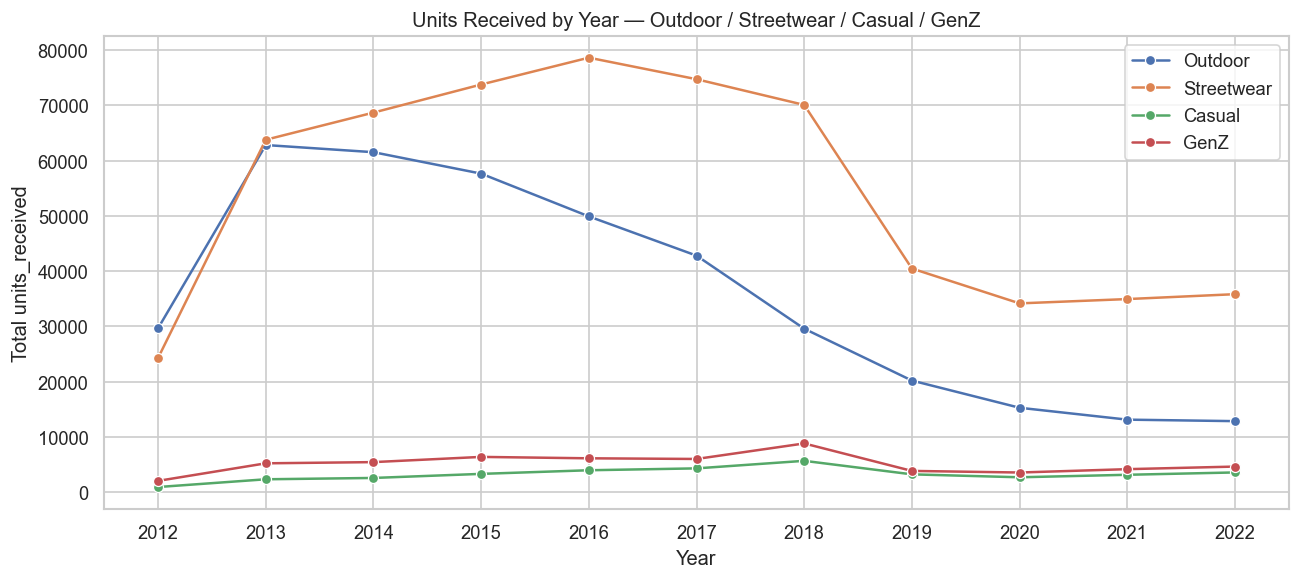


% change from first to last year (approx):
category_group
Casual        282.5
GenZ          126.2
Outdoor       -56.7
Streetwear     47.5
dtype: float64


In [35]:
# Block 2 visualization: units_received trend by category
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

inv = pd.read_csv('input/inventory.csv', parse_dates=['snapshot_date'], low_memory=False)
inv['year'] = inv['snapshot_date'].dt.year if 'year' not in inv.columns else inv['year'].astype(int)

cats = ['Outdoor', 'Streetwear', 'Casual', 'GenZ']
available = inv['category'].dropna().unique().tolist()
matched = {c: [x for x in available if x.lower() == c.lower() or c.lower() in x.lower()] for c in cats}

print('Category mapping used:')
for c, vals in matched.items():
    print(f' - {c}: {vals if vals else "NO MATCH"}')

rows = []
for c, vals in matched.items():
    if vals:
        sub = inv[inv['category'].isin(vals)].groupby('year', as_index=False)['units_received'].sum()
        sub['category_group'] = c
        rows.append(sub)

if not rows:
    print('No category matched. Check inv[category] values.')
else:
    agg = pd.concat(rows, ignore_index=True)
    plt.figure(figsize=(11, 5))
    sns.lineplot(data=agg, x='year', y='units_received', hue='category_group', marker='o')
    plt.title('Units Received by Year — Outdoor / Streetwear / Casual / GenZ')
    plt.ylabel('Total units_received')
    plt.xlabel('Year')
    plt.xticks(sorted(agg['year'].unique()))
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

    summary = agg.pivot(index='year', columns='category_group', values='units_received').sort_index()
    pct = (summary.iloc[-1] - summary.iloc[0]) / summary.iloc[0] * 100
    print('\n% change from first to last year (approx):')
    print(pct.round(1))

# BLOCK H1: REPEAT RATE & BASKET SIZE
**Goal**: Nếu STR không giảm nhiều nhưng repeat rate giảm → khách không quay lại (demand issue)

In [56]:
# H1.1 - Repeat Rate Analysis (Customer-level)

# sales_lines already has order_id; merge customer_id from orders_d


sales_with_cust = sales_lines.copy()
if 'customer_id' not in sales_with_cust.columns:
    sales_with_cust = sales_with_cust.merge(
        orders_d[['order_id', 'customer_id']], 
        on='order_id', 
        how='left'
    )

# Step 1: Find first purchase year per customer per segment
cust_first_year = (
    sales_with_cust
    .groupby(['customer_id', 'segment'])['year']
    .min()
    .reset_index()
    .rename(columns={'year': 'cohort_year'})
)

# Step 2: For each customer-segment cohort, count repeat purchases
repeat_analysis = []
for seg in sorted(sales_with_cust['segment'].dropna().unique()):
    seg_data = sales_with_cust[sales_with_cust['segment'] == seg]
    seg_cohorts = cust_first_year[cust_first_year['segment'] == seg]
    
    repeat_stats = {}
    for _, cohort_row in seg_cohorts.iterrows():
        cust_id = cohort_row['customer_id']
        cohort_y = cohort_row['cohort_year']
        
        # Count repeat purchases (year > cohort_year)
        repeat_count = len(seg_data[(seg_data['customer_id'] == cust_id) & (seg_data['year'] > cohort_y)])
        
        if cohort_y not in repeat_stats:
            repeat_stats[cohort_y] = {'total_cust': 0, 'repeat_cust': 0}
        repeat_stats[cohort_y]['total_cust'] += 1
        if repeat_count > 0:
            repeat_stats[cohort_y]['repeat_cust'] += 1
    
    for cohort_y, stats in sorted(repeat_stats.items()):
        repeat_pct = (stats['repeat_cust'] / stats['total_cust'] * 100) if stats['total_cust'] > 0 else 0
        repeat_analysis.append({
            'segment': seg,
            'cohort_year': cohort_y,
            'total_customers': stats['total_cust'],
            'repeat_customers': stats['repeat_cust'],
            'repeat_rate_%': repeat_pct
        })

repeat_df = pd.DataFrame(repeat_analysis).sort_values(['segment', 'cohort_year'])

print('\n' + '=' * 80)
print('H1.1: REPEAT RATE BY SEGMENT & COHORT YEAR (% customers who bought again)')
print('=' * 80)
for seg in sorted(repeat_df['segment'].unique()):
    seg_repeat = repeat_df[repeat_df['segment'] == seg]
    print(f'\n{seg}:')
    print(seg_repeat[['cohort_year', 'total_customers', 'repeat_customers', 'repeat_rate_%']].to_string(index=False))
    
    # Compare P1 vs P2
    p1_repeat = seg_repeat[seg_repeat['cohort_year'] <= 2018]['repeat_rate_%'].mean()
    p2_repeat = seg_repeat[seg_repeat['cohort_year'] > 2018]['repeat_rate_%'].mean()
    
    if pd.notna(p1_repeat) and pd.notna(p2_repeat):
        print(f'  P1 (cohort 2012-2018) avg repeat: {p1_repeat:.1f}%')
        print(f'  P2 (cohort 2019+) avg repeat: {p2_repeat:.1f}%')
        if p2_repeat < p1_repeat:
            print(f'  ↓ Decline: {p1_repeat - p2_repeat:.1f}pp → H1 signal ✓')
        else:
            print(f'  → No decline')


H1.1: REPEAT RATE BY SEGMENT & COHORT YEAR (% customers who bought again)

Activewear:
 cohort_year  total_customers  repeat_customers  repeat_rate_%
        2012             8318              6334      76.148113
        2013            12320              8219      66.712662
        2014             8731              4607      52.766006
        2015             6193              2647      42.741805
        2016             4466              1383      30.967309
        2017             3433               733      21.351588
        2018             2382               356      14.945424
        2019             1499               161      10.740494
        2020             1135                71       6.255507
        2021              875                24       2.742857
        2022              834                 0       0.000000
  P1 (cohort 2012-2018) avg repeat: 43.7%
  P2 (cohort 2019+) avg repeat: 4.9%
  ↓ Decline: 38.7pp → H1 signal ✓

All-weather:
 cohort_year  total_customers

# BLOCK H2: SKU-LEVEL STOCK PARADOX
**Goal**: Top 20% SKU (by revenue) có fill_rate thấp hơn bottom 80% → inventory mismatch

In [57]:
# H2.1 - SKU-level metrics (revenue-based top 20%)
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
# If sku_lifespan not yet defined, create it now
if 'sku_lifespan' not in locals():
    temp_lines = (
        order_items
        .merge(orders_d[['order_id', 'year']], on='order_id', how='inner')
        .merge(products[['product_id', 'category', 'segment', 'price', 'cogs']], on='product_id', how='left')
    )
    sku_lifespan = (
        temp_lines.groupby('product_id')
        .agg(launch_year=('year', 'min'), last_year=('year', 'max'))
        .reset_index()
    )
    sku_lifespan = sku_lifespan.merge(
        products[['product_id', 'category', 'segment', 'price', 'cogs']], on='product_id'
    )
    sku_lifespan['gross_margin_pct'] = (
        (sku_lifespan['price'] - sku_lifespan['cogs']) / sku_lifespan['price'] * 100
    )

# SKU revenue metrics
sku_revenue = (
    sales_lines
    .assign(revenue=lambda d: d['quantity'] * d['unit_price'])
    .groupby('product_id')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_units=('quantity', 'sum'),
        avg_unit_price=('unit_price', 'mean'),
        category=('category', 'first'),
        segment=('segment', 'first')
    )
    .reset_index()
)

# SKU inventory metrics
sku_inventory_metrics = (
    inventory
    .groupby('product_id')
    .agg(
        fill_rate_avg=('fill_rate', 'mean'),
        stockout_freq=('stockout_flag', 'sum'),
        stockout_pct=('stockout_flag', 'mean')
    )
    .reset_index()
)

# SKU rating
sku_rating = (
    review_base
    .groupby('product_id')
    .agg(avg_rating=('rating', 'mean'))
    .reset_index()
)

# SKU lifecycle
sku_lifecycle = sku_lifespan[['product_id', 'launch_year', 'last_year', 'gross_margin_pct']].copy()

# Merge all
sku_master = (
    sku_revenue
    .merge(sku_inventory_metrics, on='product_id', how='left')
    .merge(sku_rating, on='product_id', how='left')
    .merge(sku_lifecycle, on='product_id', how='left')
)

# Classify top 20% vs bottom 80% by revenue within segment
if 'sku_tier' not in sku_master.columns:
    sku_master['sku_tier'] = 'Bottom 80%'  # default
    for seg in sku_master['segment'].dropna().unique():
        seg_mask = sku_master['segment'] == seg
        threshold = sku_master.loc[seg_mask, 'total_revenue'].quantile(0.8)
        sku_master.loc[seg_mask & (sku_master['total_revenue'] >= threshold), 'sku_tier'] = 'Top 20%'

print('\n' + '=' * 80)
print('H2.1: SKU-LEVEL STOCK PARADOX (Top 20% vs Bottom 80% by revenue)')
print('=' * 80)

for seg in sorted(sku_master['segment'].dropna().unique()):
    seg_data = sku_master[sku_master['segment'] == seg]
    
    print(f'\n{seg} (n={len(seg_data)} SKU):')
    comparison = seg_data.groupby('sku_tier').agg({
        'fill_rate_avg': ['mean', 'median'],
        'stockout_pct': ['mean', 'median'],
        'avg_rating': ['mean', 'median'],
        'total_revenue': 'count'
    }).round(3)
    print(comparison)
    
    # Extract means
    top20_fill = seg_data[seg_data['sku_tier'] == 'Top 20%']['fill_rate_avg'].mean()
    bot80_fill = seg_data[seg_data['sku_tier'] == 'Bottom 80%']['fill_rate_avg'].mean()
    top20_stockout = seg_data[seg_data['sku_tier'] == 'Top 20%']['stockout_pct'].mean()
    bot80_stockout = seg_data[seg_data['sku_tier'] == 'Bottom 80%']['stockout_pct'].mean()
    
    print(f'\n  Fill Rate comparison:')
    print(f'    Top 20%: {top20_fill:.3f} vs Bottom 80%: {bot80_fill:.3f}', end='')
    if pd.notna(top20_fill) and pd.notna(bot80_fill) and top20_fill < bot80_fill:
        print(f' (↓ {bot80_fill - top20_fill:.3f}) → H2 signal ✓')
    else:
        print()
    
    print(f'  Stockout % comparison:')
    print(f'    Top 20%: {top20_stockout:.3f} vs Bottom 80%: {bot80_stockout:.3f}', end='')
    if pd.notna(top20_stockout) and pd.notna(bot80_stockout) and top20_stockout > bot80_stockout:
        print(f' (↑ {top20_stockout - bot80_stockout:.3f}) → H2 signal ✓')
    else:
        print()

print(f'\nSKU Master Table: {sku_master.shape}')

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\302624785.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')



H2.1: SKU-LEVEL STOCK PARADOX (Top 20% vs Bottom 80% by revenue)

Activewear (n=420 SKU):
           fill_rate_avg        stockout_pct        avg_rating         \
                    mean median         mean median       mean median   
sku_tier                                                                
Bottom 80%         0.961  0.965        0.676  0.680      3.878  3.939   
Top 20%            0.962  0.965        0.664  0.665      3.932  3.933   

           total_revenue  
                   count  
sku_tier                  
Bottom 80%           336  
Top 20%               84  

  Fill Rate comparison:
    Top 20%: 0.962 vs Bottom 80%: 0.961
  Stockout % comparison:
    Top 20%: 0.664 vs Bottom 80%: 0.676

All-weather (n=89 SKU):
           fill_rate_avg        stockout_pct        avg_rating         \
                    mean median         mean median       mean median   
sku_tier                                                                
Bottom 80%         0.962  0.965   

# BLOCK H3: DISCONTINUED MARGIN ANALYSIS
**Goal**: Những SKU bị khai tử trong Outdoor/Streetwear có margin cao hay thấp? Nếu cao → đã bỏ sai

In [58]:
# H3.1 - Discontinued SKU margin analysis

# Ensure sku_master exists (from H2.1)
if 'sku_master' not in locals():
    print("WARNING: sku_master not found. Run H2.1 cell first.")
else:
    # Add status if not present
    if 'status' not in sku_master.columns:
        sku_master['status'] = sku_master['last_year'].apply(
            lambda x: 'Discontinued' if pd.notna(x) and x < 2022 else 'Active'
        )
    
    print('\n' + '=' * 80)
    print('H3.1: DISCONTINUED MARGIN ANALYSIS (within category)')
    print('=' * 80)
    
    for cat in sorted(sku_master['category'].dropna().unique()):
        cat_data = sku_master[sku_master['category'] == cat]
        
        print(f'\n{cat}:')
        margin_by_status = cat_data.groupby('status').agg({
            'gross_margin_pct': ['mean', 'median', 'count'],
            'total_revenue': 'sum',
            'fill_rate_avg': 'mean'
        }).round(2)
        print(margin_by_status)
        
        # Summary
        disc_margin = cat_data[cat_data['status'] == 'Discontinued']['gross_margin_pct'].mean()
        active_margin = cat_data[cat_data['status'] == 'Active']['gross_margin_pct'].mean()
        
        if pd.notna(disc_margin) and pd.notna(active_margin):
            print(f'\n  Margin comparison:')
            print(f'    Discontinued: {disc_margin:.1f}%')
            print(f'    Active: {active_margin:.1f}%')
            if disc_margin > active_margin:
                print(f'    ↑ {disc_margin - active_margin:.1f}pp higher margin on discontinued → H3 signal ✓ (bỏ sai)')
            else:
                print(f'    ↓ {active_margin - disc_margin:.1f}pp lower margin on discontinued → reasonable decision')
        
        disc_fill = cat_data[cat_data['status'] == 'Discontinued']['fill_rate_avg'].mean()
        active_fill = cat_data[cat_data['status'] == 'Active']['fill_rate_avg'].mean()
        if pd.notna(disc_fill) and pd.notna(active_fill):
            print(f'\n  Fill Rate: Discontinued {disc_fill:.3f} vs Active {active_fill:.3f}')


H3.1: DISCONTINUED MARGIN ANALYSIS (within category)

Casual:
             gross_margin_pct              total_revenue fill_rate_avg
                         mean median count           sum          mean
status                                                                
Active                  22.09  22.69    63  2.887426e+08          0.96
Discontinued            23.96  23.88    49  7.652089e+07          0.96

  Margin comparison:
    Discontinued: 24.0%
    Active: 22.1%
    ↑ 1.9pp higher margin on discontinued → H3 signal ✓ (bỏ sai)

  Fill Rate: Discontinued 0.961 vs Active 0.961

GenZ:
             gross_margin_pct              total_revenue fill_rate_avg
                         mean median count           sum          mean
status                                                                
Active                  20.57  17.62    79  2.261583e+08          0.96
Discontinued            19.69  16.52    32  4.886868e+07          0.96

  Margin comparison:
    Discontinued: 19

# BLOCK SKU DEEP DIVE: Master Table per Segment

In [59]:
# SKU Deep Dive - Master Table per Segment

if 'sku_master' not in locals():
    print("WARNING: sku_master not found. Run H2.1 cell first.")
else:
    # Ensure sku_tier column exists (fallback in case H2.1 failed)
    if 'sku_tier' not in sku_master.columns:
        print("Creating sku_tier column...")
        sku_master['sku_tier'] = 'Bottom 80%'
        for seg in sku_master['segment'].dropna().unique():
            seg_mask = sku_master['segment'] == seg
            threshold = sku_master.loc[seg_mask, 'total_revenue'].quantile(0.8)
            sku_master.loc[seg_mask & (sku_master['total_revenue'] >= threshold), 'sku_tier'] = 'Top 20%'
    
    available_segs = sorted(sku_master['segment'].dropna().unique())
    
    print('\n' + '=' * 80)
    print('SKU DEEP DIVE: Master Table Preview (Top 10 SKU by revenue per segment)')
    print('=' * 80)
    
    for seg in available_segs:
        seg_table = sku_master[sku_master['segment'] == seg].sort_values('total_revenue', ascending=False)
        
        print(f'\n\n{seg} (n={len(seg_table)} SKU):')
        
        # Top 10 SKUs - only include columns that exist
        top10_cols = ['product_id', 'total_revenue', 'fill_rate_avg', 'stockout_pct', 'avg_rating', 'gross_margin_pct']
        if 'sku_tier' in seg_table.columns:
            top10_cols.append('sku_tier')
        if 'status' in seg_table.columns:
            top10_cols.append('status')
        
        top10 = seg_table.head(10)[[col for col in top10_cols if col in seg_table.columns]].copy()
        print('\nTop 10 SKUs:')
        print(top10.round(2).to_string(index=False))
        
        # Summary by tier+status
        if 'status' in seg_table.columns and 'sku_tier' in seg_table.columns:
            print(f'\n  Summary by tier & status:')
            summary = seg_table.groupby(['sku_tier', 'status']).agg({
                'fill_rate_avg': 'mean',
                'stockout_pct': 'mean',
                'gross_margin_pct': 'mean',
                'product_id': 'count'
            }).round(3)
            summary.columns = ['fill_rate', 'stockout_%', 'margin_%', 'count']
            print(summary)
        elif 'sku_tier' in seg_table.columns:
            print(f'\n  Summary by tier:')
            summary = seg_table.groupby('sku_tier').agg({
                'fill_rate_avg': 'mean',
                'stockout_pct': 'mean',
                'gross_margin_pct': 'mean',
                'product_id': 'count'
            }).round(3)
            summary.columns = ['fill_rate', 'stockout_%', 'margin_%', 'count']
            print(summary)


SKU DEEP DIVE: Master Table Preview (Top 10 SKU by revenue per segment)


Activewear (n=420 SKU):

Top 10 SKUs:
 product_id  total_revenue  fill_rate_avg  stockout_pct  avg_rating  gross_margin_pct sku_tier status
        734    74918700.59           0.96          0.69        3.92             14.87  Top 20% Active
        733    74302376.47           0.97          0.63        3.96             47.78  Top 20% Active
        763    38975481.46           0.95          0.69        3.97             38.94  Top 20% Active
        764    38565118.21           0.94          0.62        3.88              7.28  Top 20% Active
        762    31958426.52           0.97          0.70        3.90              5.00  Top 20% Active
        761    31813280.53           0.97          0.66        3.88              5.00  Top 20% Active
        760    31050956.60           0.96          0.71        3.92             33.60  Top 20% Active
        759    30295764.91           0.97          0.67        3.88    

# VERDICT SCORECARD: H1 vs H2 vs H3

In [66]:
# VERDICT SCORECARD - Synthesize all hypotheses

print('\n' + '=' * 80)
print('FINAL VERDICT: H1 vs H2 vs H3')
print('=' * 80)

# Ensure all required data exists
if 'repeat_df' not in locals():
    print("ERROR: repeat_df not found. Run H1.1 cell first.")
    
elif 'sku_master' not in locals():
    print("ERROR: sku_master not found. Run H2.1 cell first.")
    
else:
    # Ensure sku_tier exists (fallback)
    if 'sku_tier' not in sku_master.columns:
        print("Creating sku_tier column...")
        sku_master['sku_tier'] = 'Bottom 80%'
        for seg in sku_master['segment'].dropna().unique():
            seg_mask = sku_master['segment'] == seg
            threshold = sku_master.loc[seg_mask, 'total_revenue'].quantile(0.8)
            sku_master.loc[seg_mask & (sku_master['total_revenue'] >= threshold), 'sku_tier'] = 'Top 20%'
    
    # Reconstruct seg_year if needed (from cell 2)
    if 'seg_year' not in locals():
        seg_year = (
            sales_lines.groupby(['year', 'segment'], as_index=False)
            .agg(units=('quantity', 'sum'))
        )
    
    # Reconstruct active_sku_year if needed (from H3 cell)
    if 'active_sku_year' not in locals():
        temp_lines = (
            order_items
            .merge(orders_d[['order_id', 'year']], on='order_id', how='inner')
            .merge(products[['product_id', 'category', 'segment']], on='product_id', how='left')
        )
        active_sku_year = (
            temp_lines.groupby(['year', 'segment'])['product_id']
            .nunique()
            .reset_index(name='active_skus')
        )
    
    scorecard = []
    
    # Iterate through segments and compute verdict
    for seg in sorted(repeat_df['segment'].unique()):
        # H1 signals
        seg_repeat = repeat_df[repeat_df['segment'] == seg]
        p1_repeat = seg_repeat[seg_repeat['cohort_year'] <= 2018]['repeat_rate_%'].mean()
        p2_repeat = seg_repeat[seg_repeat['cohort_year'] > 2018]['repeat_rate_%'].mean()
        
        seg_sales_yr = seg_year[seg_year['segment'] == seg]
        p1_units = seg_sales_yr[seg_sales_yr['year'] <= 2018]['units'].mean()
        p2_units = seg_sales_yr[seg_sales_yr['year'] > 2018]['units'].mean()
        
        h1_repeat_signal = '✓' if (pd.notna(p2_repeat) and pd.notna(p1_repeat) and p2_repeat < p1_repeat) else '✗'
        h1_units_signal = '✓' if (pd.notna(p2_units) and pd.notna(p1_units) and p2_units < p1_units) else '✗'
        
        # H2 signals
        seg_master = sku_master[sku_master['segment'] == seg]
        
        # Extra safety check for sku_tier
        if 'sku_tier' not in seg_master.columns or seg_master['sku_tier'].isna().all():
            threshold = seg_master['total_revenue'].quantile(0.8)
            seg_master = seg_master.copy()
            seg_master['sku_tier'] = seg_master['total_revenue'].apply(
                lambda x: 'Top 20%' if pd.notna(x) and x >= threshold else 'Bottom 80%'
            )
        
        top20_fill = seg_master[seg_master['sku_tier'] == 'Top 20%']['fill_rate_avg'].mean()
        bot80_fill = seg_master[seg_master['sku_tier'] == 'Bottom 80%']['fill_rate_avg'].mean()
        h2_fill_signal = '✓' if (pd.notna(top20_fill) and pd.notna(bot80_fill) and top20_fill < bot80_fill) else '✗'
        
        # H3 signals
        active_skus_p1 = active_sku_year[(active_sku_year['segment'] == seg) & (active_sku_year['year'] <= 2018)]['active_skus'].mean()
        active_skus_p2 = active_sku_year[(active_sku_year['segment'] == seg) & (active_sku_year['year'] > 2018)]['active_skus'].mean()
        h3_assort_signal = '✓' if (pd.notna(active_skus_p1) and pd.notna(active_skus_p2) and active_skus_p2 < active_skus_p1) else '✗'
        
        scorecard.append({
            'Segment': seg,
            'H1_Repeat': h1_repeat_signal,
            'H1_Units': h1_units_signal,
            'H2_FillRate': h2_fill_signal,
            'H3_Assort': h3_assort_signal
        })
    
    scorecard_df = pd.DataFrame(scorecard)
    
    print('\nVERDICT SCORECARD (✓ = supports hypothesis, ✗ = does not support)')
    print('=' * 80)
    print(scorecard_df.to_string(index=False))
    
    print('\n' + '=' * 80)
    print('FINAL VERDICT BY SEGMENT')
    print('=' * 80)
    
    for seg in sorted(repeat_df['segment'].unique()):
        seg_score = scorecard_df[scorecard_df['Segment'] == seg]
        if len(seg_score) == 0:
            continue
        seg_score = seg_score.iloc[0]
        
        h1_count = (seg_score['H1_Repeat'] == '✓').astype(int) + (seg_score['H1_Units'] == '✓').astype(int)
        h2_support = seg_score['H2_FillRate']
        h3_support = seg_score['H3_Assort']
        
        print(f'\n{seg}:')
        print(f'  H1 (Appeal): {h1_count}/2 signals → {"SUPPORTED" if h1_count >= 1 else "weak"}')
        print(f'  H2 (Ops): {("SUPPORTED" if h2_support == "✓" else "NOT supported")}')
        print(f'  H3 (Assort): {("SUPPORTED" if h3_support == "✓" else "NOT supported")}')
        
        if h2_support == '✓' or h3_support == '✓':
            print(f'  ➜ VERDICT: Supply-side issue (H2 or H3)')
        elif h1_count >= 1:
            print(f'  ➜ VERDICT: Demand-side issue (H1)')
        else:
            print(f'  ➜ VERDICT: Mixed or unclear')


FINAL VERDICT: H1 vs H2 vs H3


KeyError: 'segment'

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\3151827601.py:95: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\3151827601.py:95: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell Gaming\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell Gaming\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


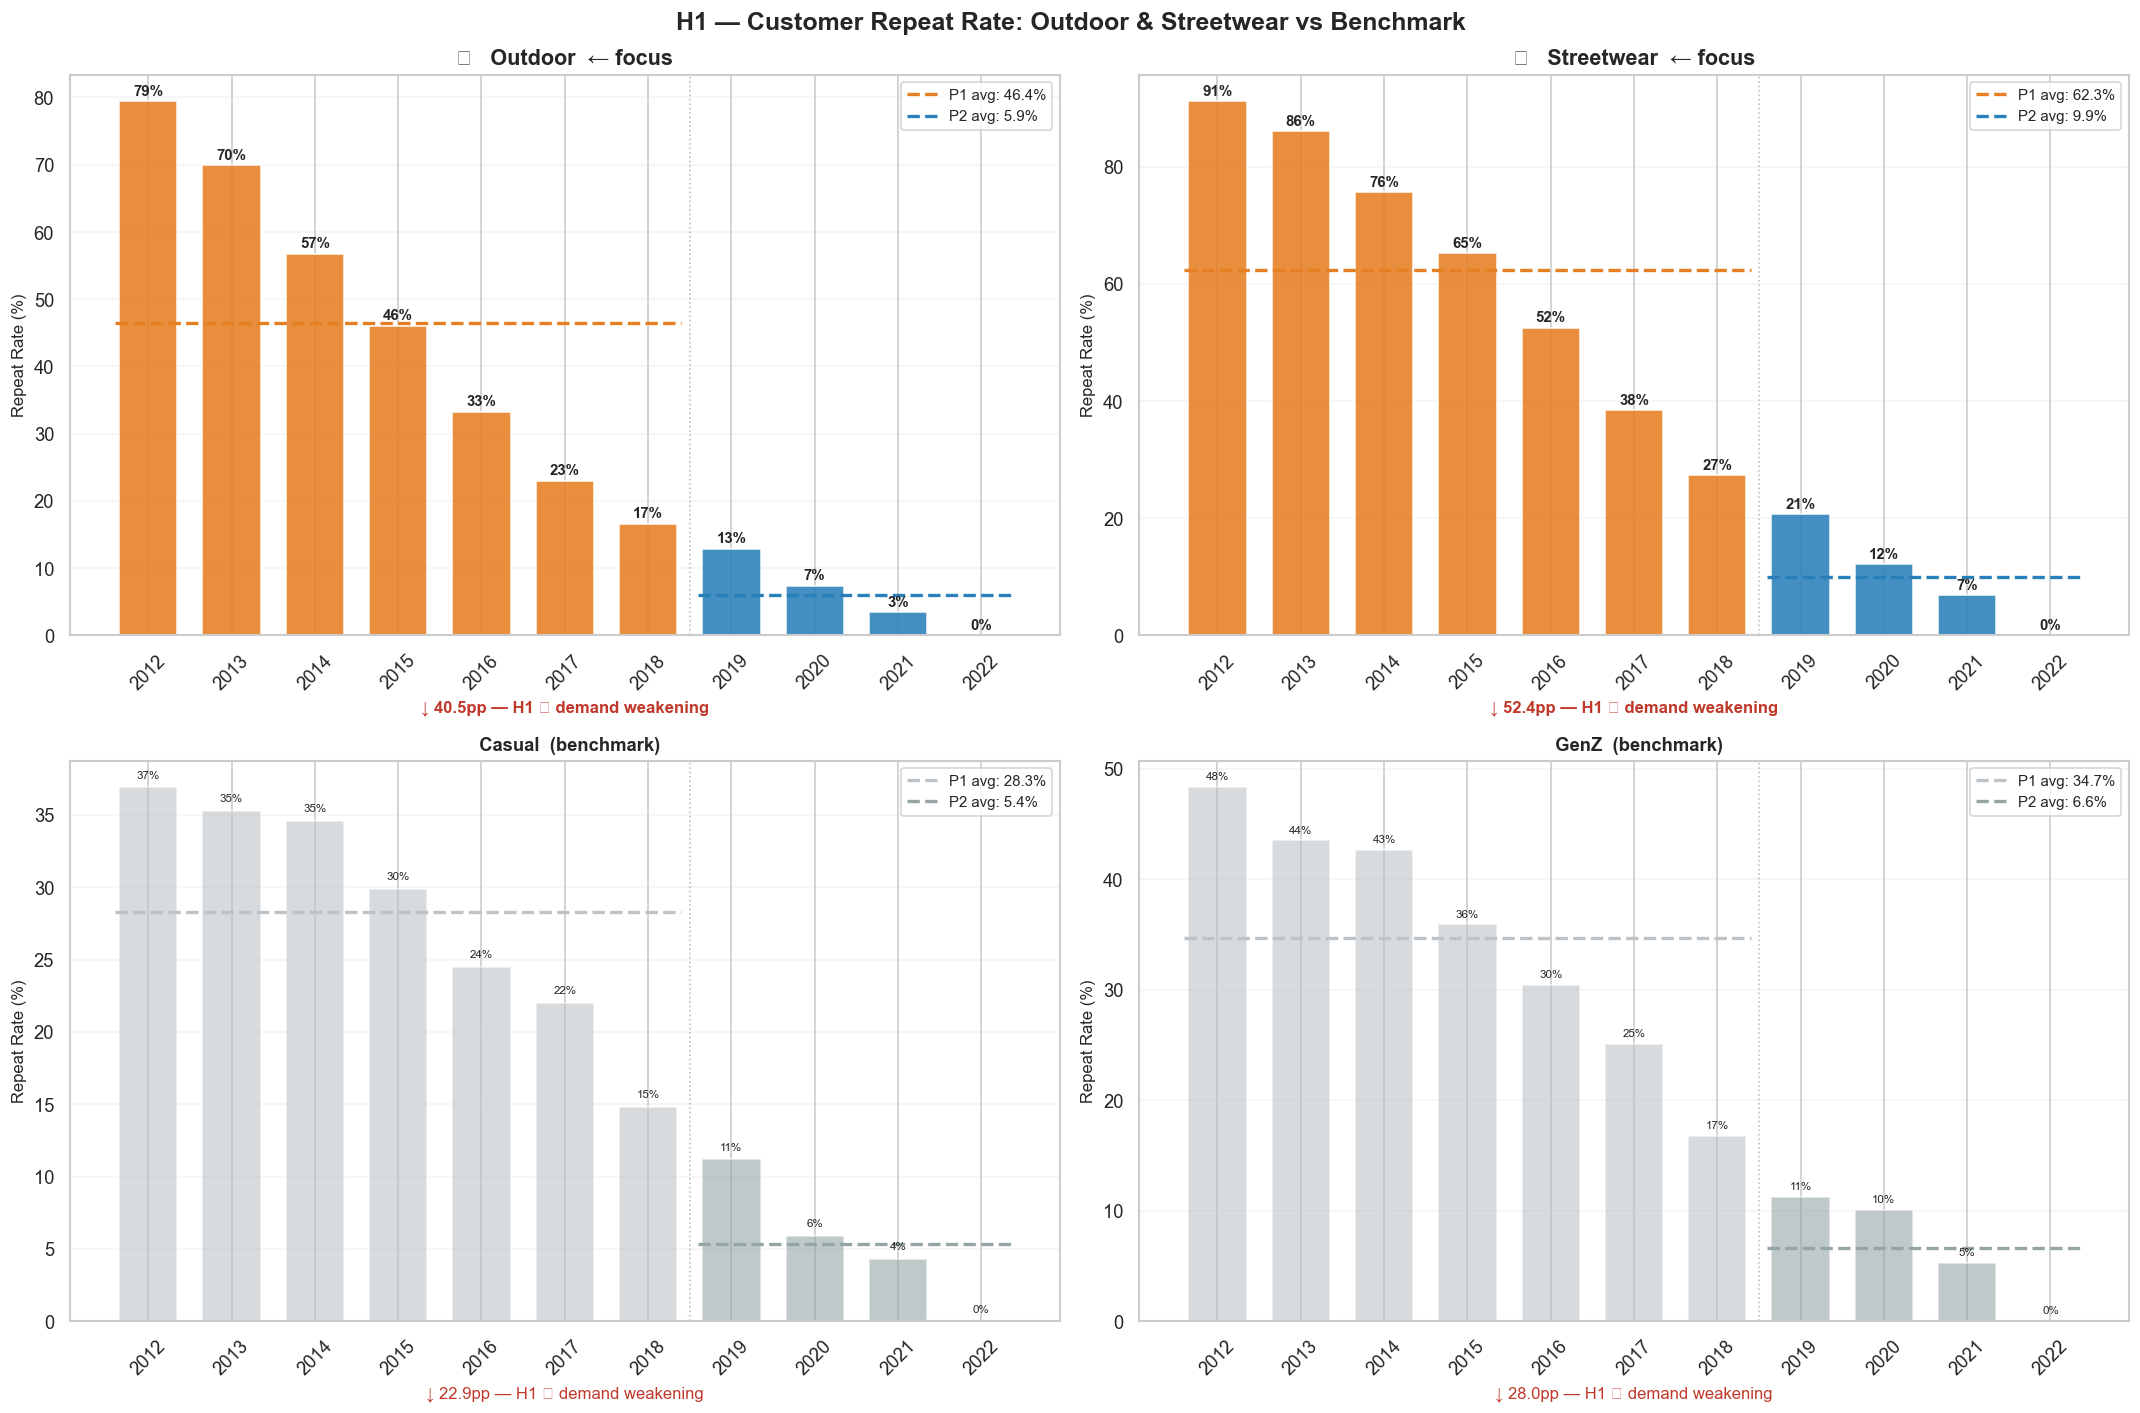

In [70]:
# VIZ-1: Repeat Rate by Category — Outdoor & Streetwear focus
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Rebuild repeat at CATEGORY level
sales_with_cust = sales_lines.merge(
    orders_d[['order_id', 'customer_id']], on='order_id', how='inner'
)

cust_first_year = (
    sales_with_cust.groupby(['customer_id', 'category'])['year']
    .min().reset_index().rename(columns={'year': 'cohort_year'})
)

repeat_cat = []
for cat in sorted(sales_with_cust['category'].dropna().unique()):
    cat_data = sales_with_cust[sales_with_cust['category'] == cat]
    cat_cohorts = cust_first_year[cust_first_year['category'] == cat]
    stats = {}
    for _, row in cat_cohorts.iterrows():
        cid, cy = row['customer_id'], row['cohort_year']
        has_repeat = len(cat_data[(cat_data['customer_id'] == cid) & (cat_data['year'] > cy)]) > 0
        stats.setdefault(cy, {'total': 0, 'repeat': 0})
        stats[cy]['total'] += 1
        if has_repeat:
            stats[cy]['repeat'] += 1
    for cy, s in sorted(stats.items()):
        repeat_cat.append({
            'category': cat, 'cohort_year': cy,
            'total_customers': s['total'], 'repeat_customers': s['repeat'],
            'repeat_rate_%': round(s['repeat'] / s['total'] * 100, 1) if s['total'] > 0 else 0
        })

repeat_cat_df = pd.DataFrame(repeat_cat)

# Plot: Outdoor & Streetwear full-size, Casual & GenZ smaller (benchmark)
TARGET = ['Outdoor', 'Streetwear']
BENCH  = ['Casual', 'GenZ']
ALL_CATS = TARGET + BENCH

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for idx, cat in enumerate(ALL_CATS):
    ax = axes[idx // 2][idx % 2]
    d = repeat_cat_df[repeat_cat_df['category'] == cat].sort_values('cohort_year')
    if d.empty:
        ax.set_visible(False)
        continue

    is_focus = cat in TARGET
    p1_color = '#E67E22' if is_focus else '#BDC3C7'
    p2_color = '#2980B9' if is_focus else '#95A5A6'
    alpha    = 0.88 if is_focus else 0.6

    colors = [p1_color if y <= 2018 else p2_color for y in d['cohort_year']]
    bars = ax.bar(d['cohort_year'], d['repeat_rate_%'], color=colors, alpha=alpha, width=0.7)

    p1 = d[d['cohort_year'] <= 2018]['repeat_rate_%'].mean()
    p2 = d[d['cohort_year'] > 2018]['repeat_rate_%'].mean()
    years = d['cohort_year'].values
    ax.hlines(p1, xmin=years.min()-0.4, xmax=2018.4,
              colors=p1_color, linestyles='--', lw=2, label=f'P1 avg: {p1:.1f}%')
    ax.hlines(p2, xmin=2018.6, xmax=years.max()+0.4,
              colors=p2_color, linestyles='--', lw=2, label=f'P2 avg: {p2:.1f}%')
    ax.axvline(2018.5, color='gray', linestyle=':', lw=1, alpha=0.5)

    for bar, val in zip(bars, d['repeat_rate_%']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', va='bottom',
                fontsize=9 if is_focus else 7, fontweight='bold' if is_focus else 'normal')

    delta = p2 - p1
    if delta < -5:
        verdict = f'↓ {abs(delta):.1f}pp — H1 ✓ demand weakening'
        vcolor = '#C0392B'
    elif delta < 0:
        verdict = f'↓ {abs(delta):.1f}pp — mild decline'
        vcolor = '#E67E22'
    else:
        verdict = f'Δ {delta:+.1f}pp — stable'
        vcolor = '#27AE60'

    label = f'{"🔴 " if is_focus else ""}  {cat}{"  ← focus" if is_focus else "  (benchmark)"}'
    ax.set_title(label, fontweight='bold', fontsize=13 if is_focus else 11)
    ax.set_xlabel(verdict, fontsize=10, color=vcolor, fontweight='bold' if is_focus else 'normal')
    ax.set_ylabel('Repeat Rate (%)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_xticks(d['cohort_year'])
    ax.set_xticklabels(d['cohort_year'].astype(int), rotation=45)

fig.suptitle('H1 — Customer Repeat Rate: Outdoor & Streetwear vs Benchmark',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\3172039941.py:95: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\3172039941.py:95: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell Gaming\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell Gaming\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


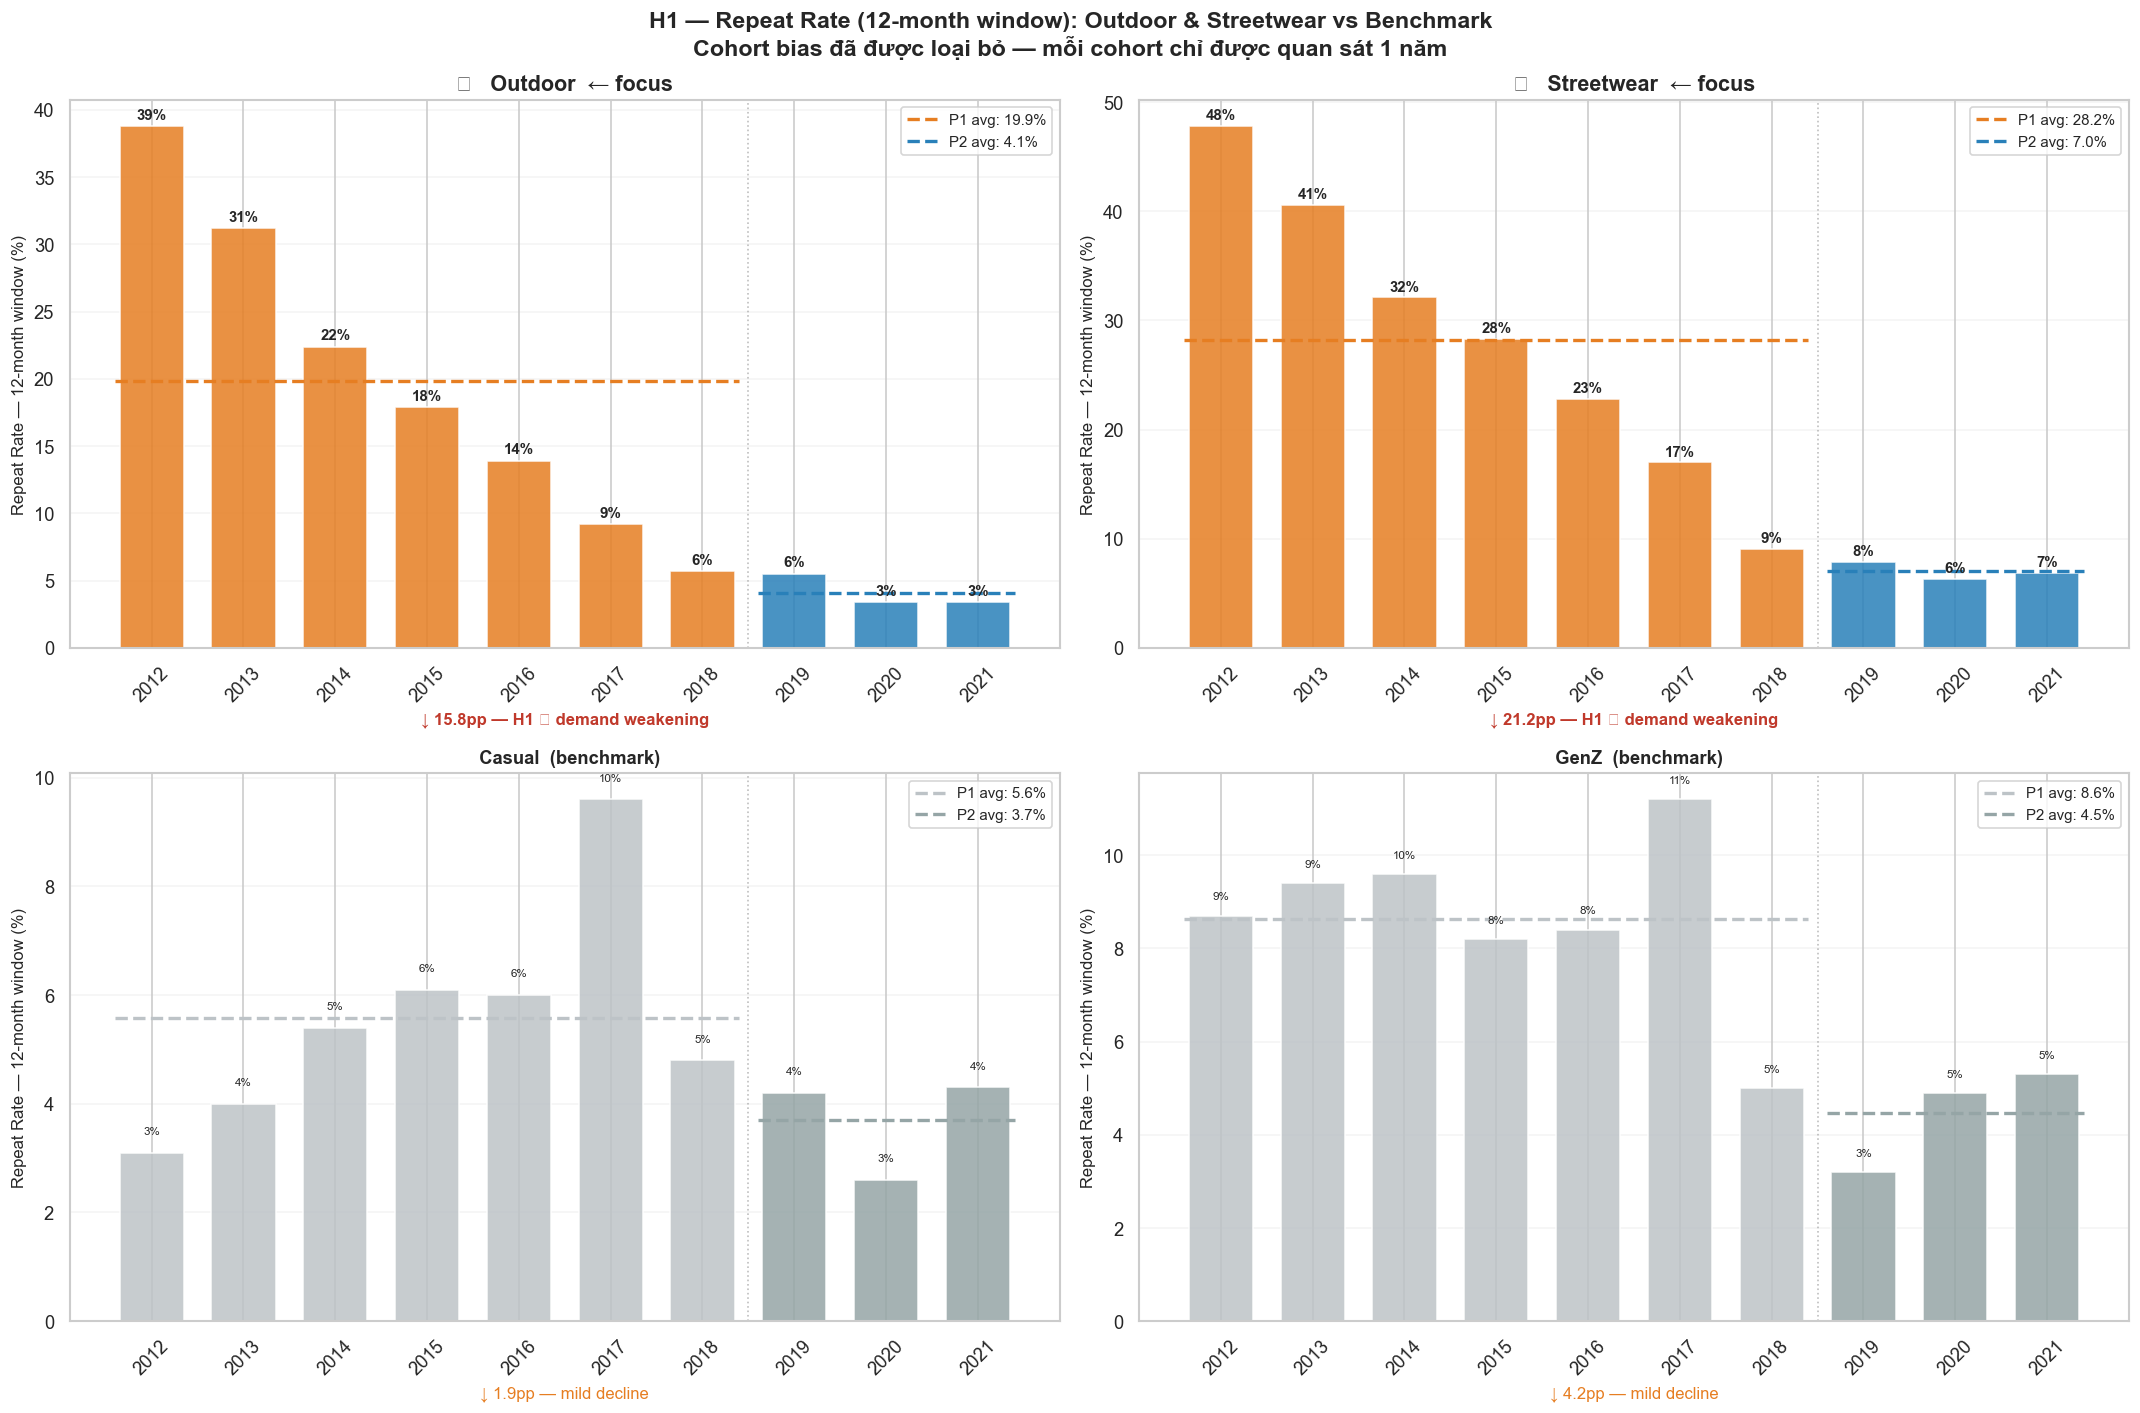

In [76]:
# VIZ-1 FIX: Repeat Rate với fixed 12-month window
WINDOW = 1  # năm

repeat_fixed = []
for cat in sorted(sales_with_cust['category'].dropna().unique()):
    cat_data = sales_with_cust[sales_with_cust['category'] == cat]
    cat_cohorts = cust_first_year[cust_first_year['category'] == cat]
    # Chỉ lấy cohort đến 2021 để có đủ 1 năm window
    cat_cohorts = cat_cohorts[cat_cohorts['cohort_year'] <= 2021]
    
    stats = {}
    for _, row in cat_cohorts.iterrows():
        cid, cy = row['customer_id'], row['cohort_year']
        # Chỉ đếm repeat trong năm tiếp theo
        has_repeat = len(cat_data[
            (cat_data['customer_id'] == cid) &
            (cat_data['year'] > cy) &
            (cat_data['year'] <= cy + WINDOW)
        ]) > 0
        stats.setdefault(cy, {'total': 0, 'repeat': 0})
        stats[cy]['total'] += 1
        if has_repeat:
            stats[cy]['repeat'] += 1
    
    for cy, s in sorted(stats.items()):
        repeat_fixed.append({
            'category': cat, 'cohort_year': cy,
            'total_customers': s['total'],
            'repeat_customers': s['repeat'],
            'repeat_rate_%': round(s['repeat'] / s['total'] * 100, 1) if s['total'] > 0 else 0
        })

repeat_fixed_df = pd.DataFrame(repeat_fixed)

# Plot lại y hệt VIZ-1 nhưng dùng repeat_fixed_df
TARGET = ['Outdoor', 'Streetwear']
BENCH  = ['Casual', 'GenZ']
ALL_CATS = TARGET + BENCH

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for idx, cat in enumerate(ALL_CATS):
    ax = axes[idx // 2][idx % 2]
    d = repeat_fixed_df[repeat_fixed_df['category'] == cat].sort_values('cohort_year')
    if d.empty:
        ax.set_visible(False)
        continue

    is_focus = cat in TARGET
    p1_color = '#E67E22' if is_focus else '#BDC3C7'
    p2_color = '#2980B9' if is_focus else '#95A5A6'

    colors = [p1_color if y <= 2018 else p2_color for y in d['cohort_year']]
    bars = ax.bar(d['cohort_year'], d['repeat_rate_%'], color=colors, alpha=0.85, width=0.7)

    p1 = d[d['cohort_year'] <= 2018]['repeat_rate_%'].mean()
    p2 = d[d['cohort_year'] > 2018]['repeat_rate_%'].mean()
    years = d['cohort_year'].values
    ax.hlines(p1, xmin=years.min()-0.4, xmax=2018.4,
              colors=p1_color, linestyles='--', lw=2, label=f'P1 avg: {p1:.1f}%')
    ax.hlines(p2, xmin=2018.6, xmax=years.max()+0.4,
              colors=p2_color, linestyles='--', lw=2, label=f'P2 avg: {p2:.1f}%')
    ax.axvline(2018.5, color='gray', linestyle=':', lw=1, alpha=0.5)

    for bar, val in zip(bars, d['repeat_rate_%']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.0f}%', ha='center', va='bottom',
                fontsize=9 if is_focus else 7,
                fontweight='bold' if is_focus else 'normal')

    delta = p2 - p1
    if delta < -5:
        verdict = f'↓ {abs(delta):.1f}pp — H1 ✓ demand weakening'
        vcolor = '#C0392B'
    elif delta < 0:
        verdict = f'↓ {abs(delta):.1f}pp — mild decline'
        vcolor = '#E67E22'
    else:
        verdict = f'Δ {delta:+.1f}pp — stable / improving'
        vcolor = '#27AE60'

    label = f'{"🔴 " if is_focus else ""}{"  " + cat}{"  ← focus" if is_focus else "  (benchmark)"}'
    ax.set_title(label, fontweight='bold', fontsize=13 if is_focus else 11)
    ax.set_xlabel(verdict, fontsize=10, color=vcolor,
                  fontweight='bold' if is_focus else 'normal')
    ax.set_ylabel('Repeat Rate — 12-month window (%)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_xticks(d['cohort_year'])
    ax.set_xticklabels(d['cohort_year'].astype(int), rotation=45)

fig.suptitle('H1 — Repeat Rate (12-month window): Outdoor & Streetwear vs Benchmark\n'
             'Cohort bias đã được loại bỏ — mỗi cohort chỉ được quan sát 1 năm',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\458495603.py:90: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\458495603.py:90: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_1932\458495603.py:90: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell Gaming\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell Gaming\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Dell Gaming\AppData\Roaming\Python\Python312\site-packages\IPython\c

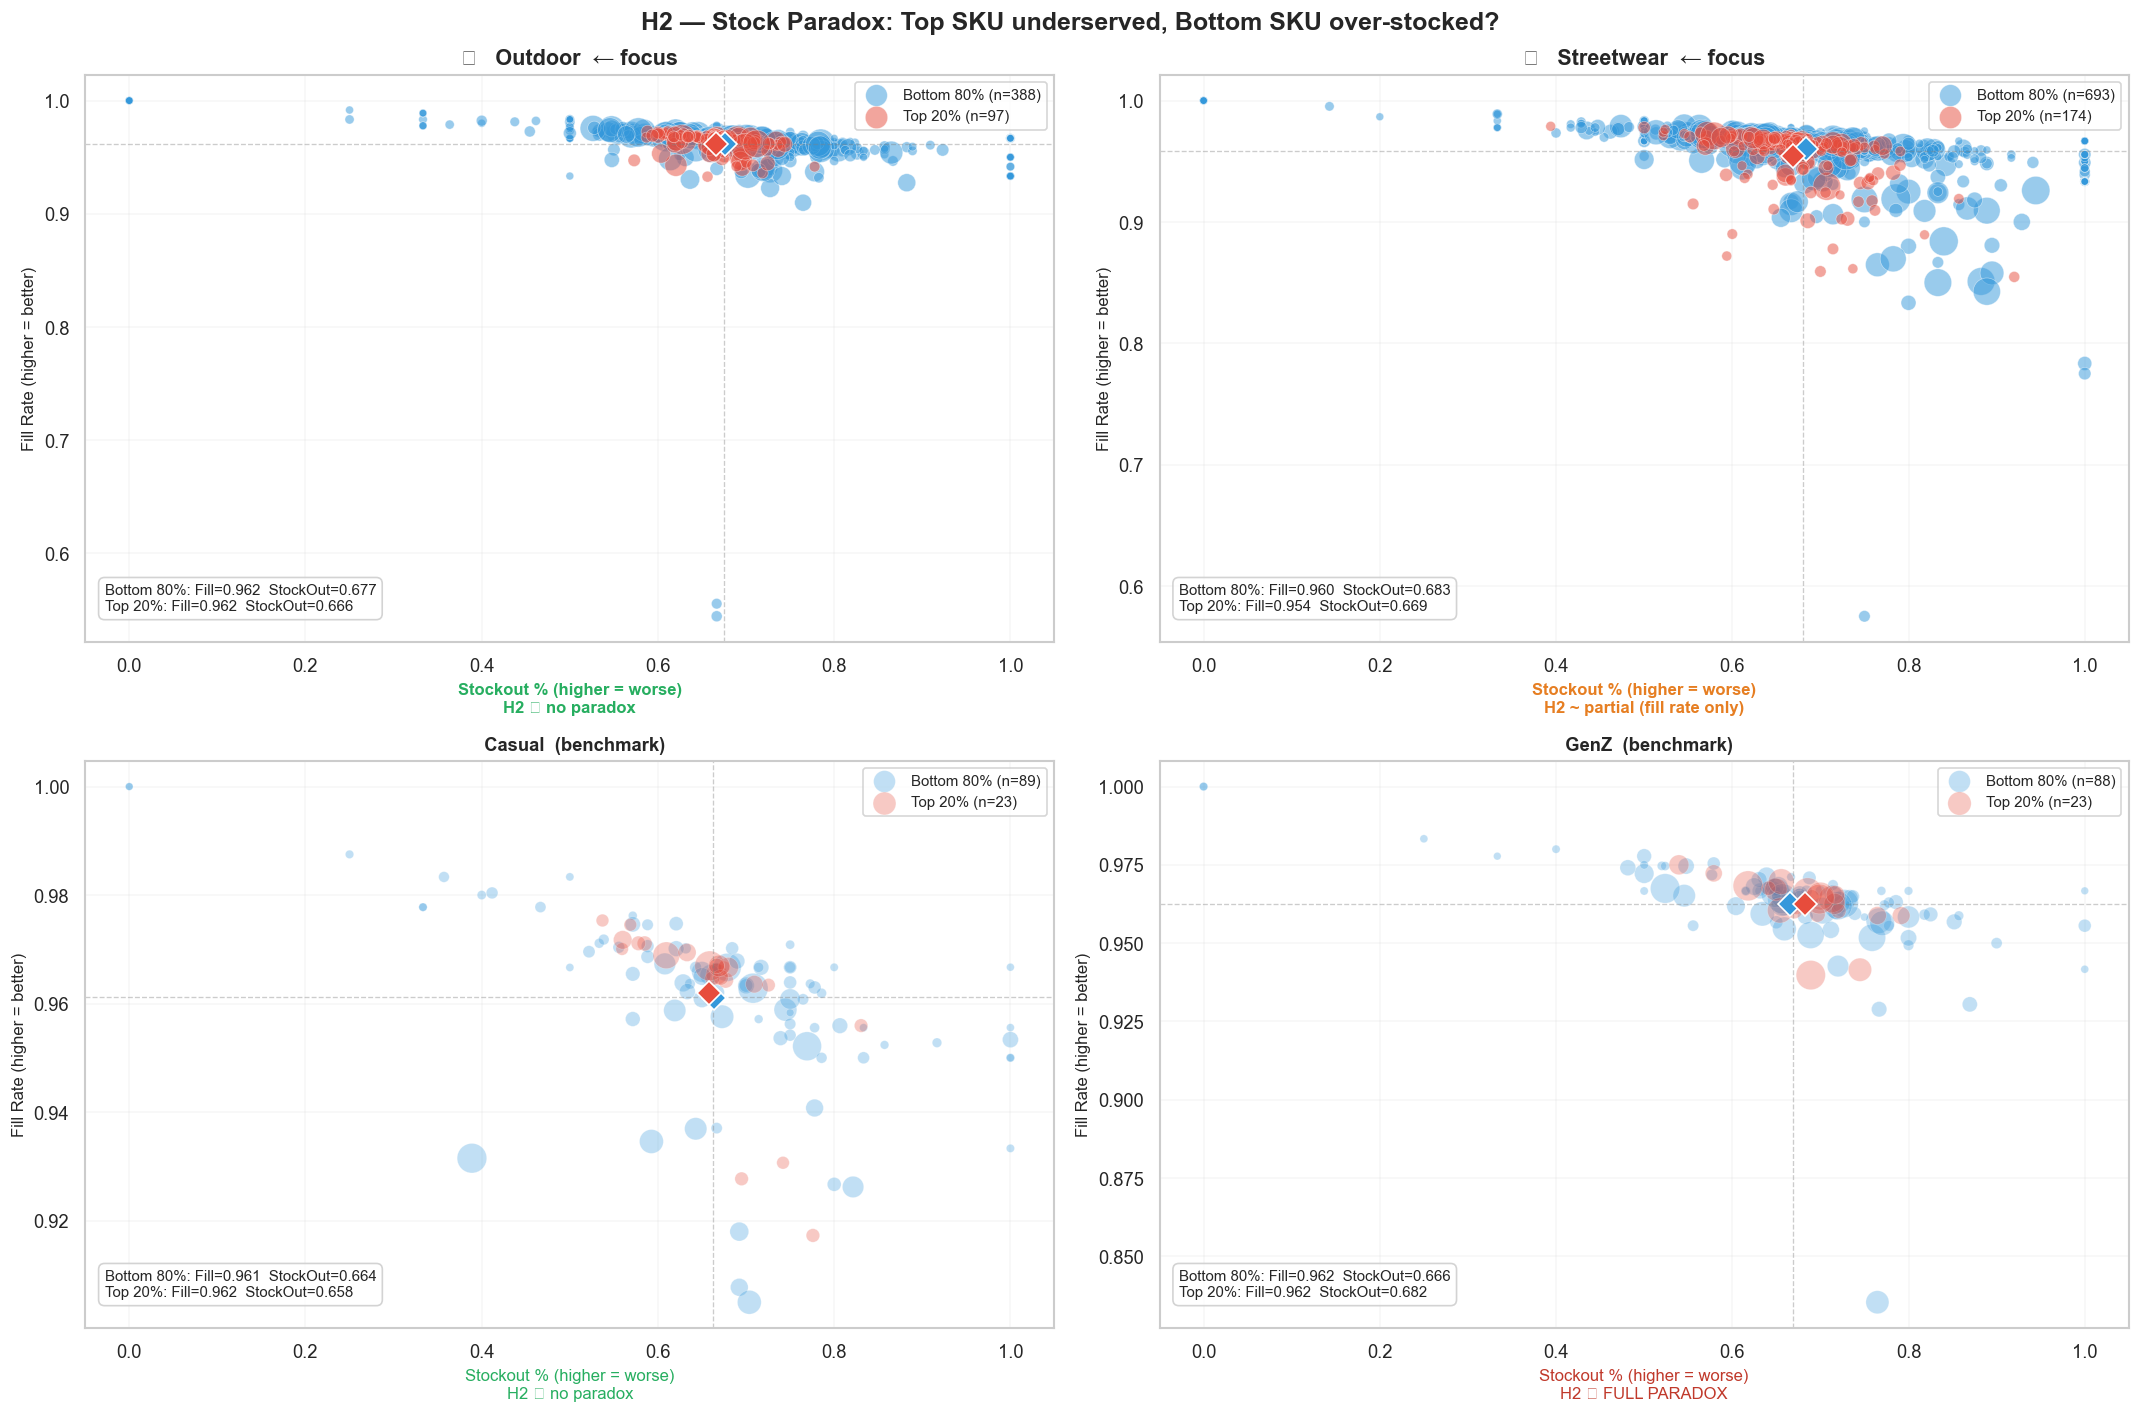

In [77]:
# VIZ-2: Stock Paradox — Outdoor & Streetwear focus, 2x2 grid
# sales_lines does not have a precomputed revenue column, so derive it here
sku_rev_cat = (
    sales_lines.assign(revenue=lambda d: d['quantity'] * d['price'])
    .groupby(['product_id', 'category'], as_index=False)
    .agg(total_revenue=('revenue', 'sum'), total_units=('quantity', 'sum'))
)
sku_inv_cat = (
    inventory.groupby('product_id', as_index=False)
    .agg(fill_rate_avg=('fill_rate', 'mean'), stockout_pct=('stockout_flag', 'mean'))
)
sku_rating_cat = (
    review_base.groupby('product_id', as_index=False)
    .agg(avg_rating=('rating', 'mean'))
)
sku_master_cat = (
    sku_rev_cat
    .merge(sku_inv_cat, on='product_id', how='left')
    .merge(sku_rating_cat, on='product_id', how='left')
    .merge(sku_lifespan[['product_id', 'gross_margin_pct', 'launch_year', 'last_year']], on='product_id', how='left')
)
sku_master_cat['sku_tier'] = 'Bottom 80%'
for cat in sku_master_cat['category'].dropna().unique():
    mask = sku_master_cat['category'] == cat
    thresh = sku_master_cat.loc[mask, 'total_revenue'].quantile(0.8)
    sku_master_cat.loc[mask & (sku_master_cat['total_revenue'] >= thresh), 'sku_tier'] = 'Top 20%'

TARGET = ['Outdoor', 'Streetwear']
BENCH  = ['Casual', 'GenZ']
ALL_CATS = TARGET + BENCH

tier_colors = {'Top 20%': '#E74C3C', 'Bottom 80%': '#3498DB'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for idx, cat in enumerate(ALL_CATS):
    ax = axes[idx // 2][idx % 2]
    d = sku_master_cat[sku_master_cat['category'] == cat].dropna(subset=['fill_rate_avg', 'stockout_pct'])
    is_focus = cat in TARGET

    for tier, grp in d.groupby('sku_tier'):
        size = ((grp['total_revenue'] / grp['total_revenue'].max()) * 300 + 20).clip(lower=15)
        ax.scatter(grp['stockout_pct'], grp['fill_rate_avg'],
                   s=size, alpha=0.5 if is_focus else 0.3,
                   color=tier_colors[tier],
                   label=f'{tier} (n={len(grp)})',
                   edgecolors='white', linewidth=0.4)

    ax.axhline(d['fill_rate_avg'].mean(), color='gray', linestyle='--', lw=0.8, alpha=0.4)
    ax.axvline(d['stockout_pct'].mean(), color='gray', linestyle='--', lw=0.8, alpha=0.4)

    summary_lines = []
    for tier, grp in d.groupby('sku_tier'):
        mx, my = grp['stockout_pct'].mean(), grp['fill_rate_avg'].mean()
        ax.plot(mx, my, marker='D', markersize=10, color=tier_colors[tier], zorder=5,
                markeredgecolor='white', markeredgewidth=1)
        summary_lines.append(f'{tier}: Fill={my:.3f}  StockOut={mx:.3f}')

    top_f = d[d['sku_tier'] == 'Top 20%']['fill_rate_avg'].mean()
    bot_f = d[d['sku_tier'] == 'Bottom 80%']['fill_rate_avg'].mean()
    top_so = d[d['sku_tier'] == 'Top 20%']['stockout_pct'].mean()
    bot_so = d[d['sku_tier'] == 'Bottom 80%']['stockout_pct'].mean()

    if pd.notna(top_f) and pd.notna(bot_f) and top_f < bot_f and top_so > bot_so:
        signal = 'H2 ✓ FULL PARADOX'
        scolor = '#C0392B'
    elif pd.notna(top_f) and pd.notna(bot_f) and top_f < bot_f:
        signal = 'H2 ~ partial (fill rate only)'
        scolor = '#E67E22'
    else:
        signal = 'H2 ✗ no paradox'
        scolor = '#27AE60'

    # Summary box inside plot
    summary_text = '\n'.join(summary_lines)
    ax.text(0.02, 0.05, summary_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#ccc'))

    label = f'{"🔴 " if is_focus else ""}  {cat}{"  ← focus" if is_focus else "  (benchmark)"}'
    ax.set_title(label, fontweight='bold', fontsize=13 if is_focus else 11)
    ax.set_xlabel(f'Stockout % (higher = worse)\n{signal}', fontsize=10, color=scolor,
                  fontweight='bold' if is_focus else 'normal')
    ax.set_ylabel('Fill Rate (higher = better)', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.15)

fig.suptitle('H2 — Stock Paradox: Top SKU underserved, Bottom SKU over-stocked?',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

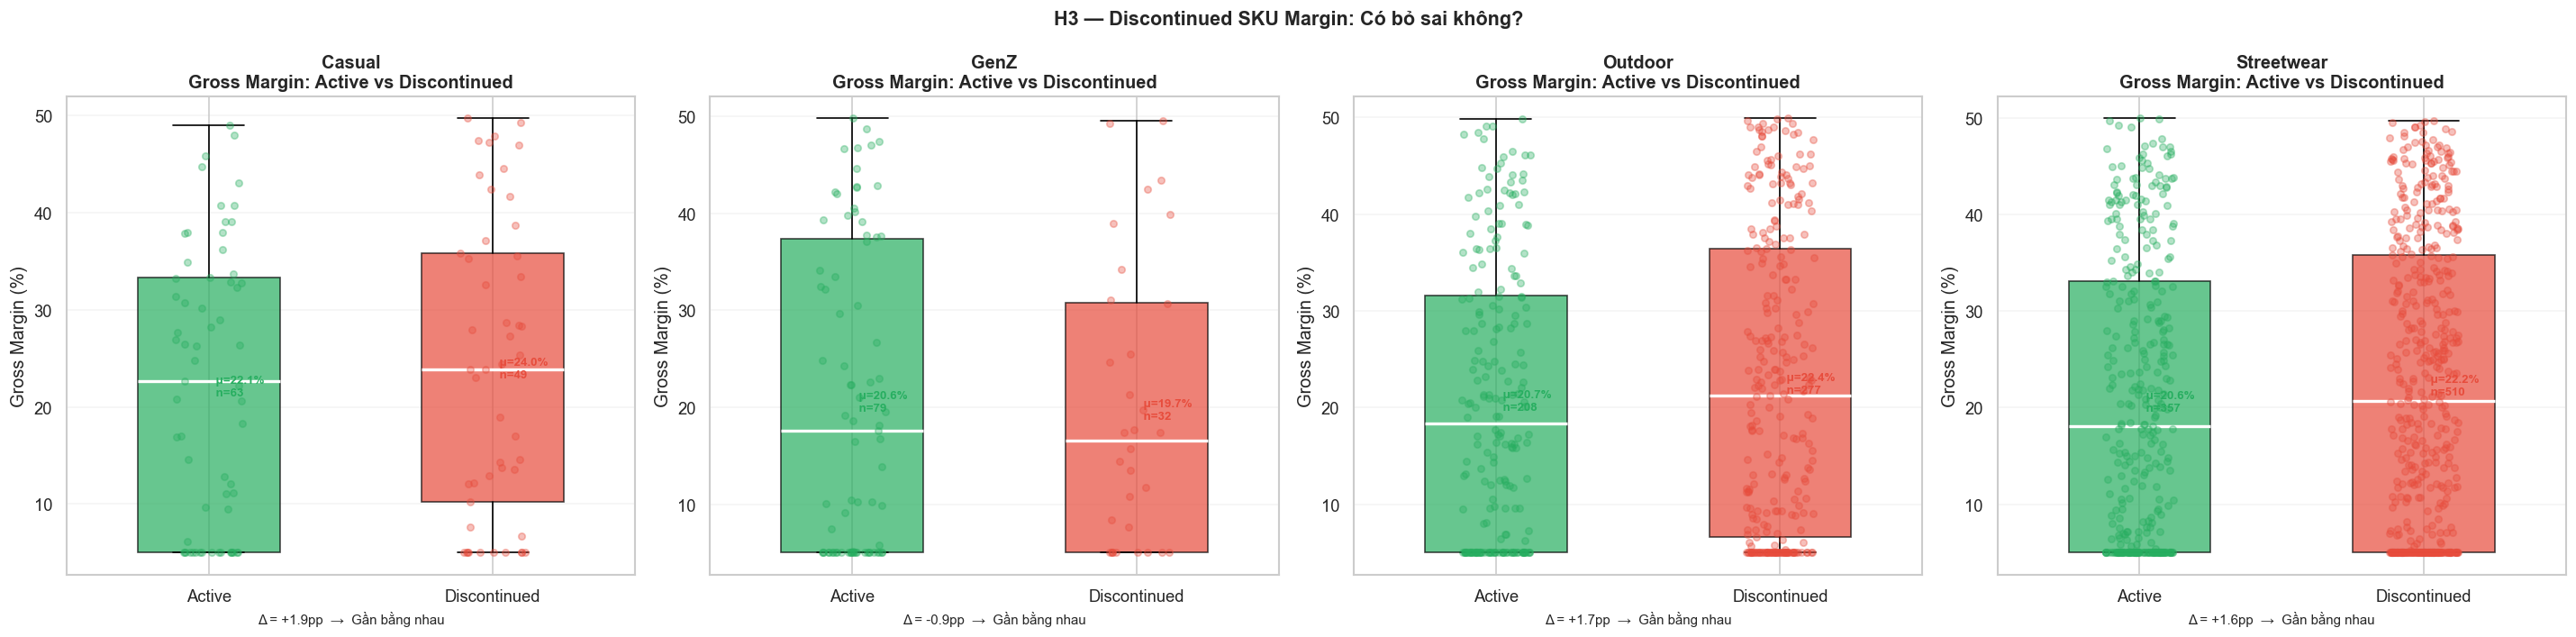

In [80]:
# VIZ-3: H3 Discontinued Margin Analysis
if 'status' not in sku_master_cat.columns:
    sku_master_cat['status'] = sku_master_cat['last_year'].apply(
        lambda x: 'Discontinued' if pd.notna(x) and x < 2022 else 'Active'
    )

cats = sorted(sku_master_cat['category'].dropna().unique())
n = len(cats)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), squeeze=False)
axes = axes[0]

status_colors = {'Active': '#27AE60', 'Discontinued': '#E74C3C'}

for ax, cat in zip(axes, cats):
    cat_data = sku_master_cat[sku_master_cat['category'] == cat].dropna(subset=['gross_margin_pct', 'status'])
    
    # Box plot
    groups = [cat_data[cat_data['status'] == s]['gross_margin_pct'].dropna() for s in ['Active', 'Discontinued']]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    
    for patch, (status, color) in zip(bp['boxes'], status_colors.items()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Overlay individual points
    for i, (status, color) in enumerate(status_colors.items(), 1):
        g = cat_data[cat_data['status'] == status]['gross_margin_pct'].dropna()
        ax.scatter([i + np.random.uniform(-0.12, 0.12, len(g))], g,
                   alpha=0.35, s=20, color=color, zorder=3)
        ax.text(i, g.mean(), f'  μ={g.mean():.1f}%\n  n={len(g)}', 
                fontsize=8, va='center', color=color, fontweight='bold')
    
    ax.set_xticklabels(['Active', 'Discontinued'])
    ax.set_title(f'{cat}\nGross Margin: Active vs Discontinued', fontweight='bold')
    ax.set_ylabel('Gross Margin (%)')
    ax.grid(True, alpha=0.2, axis='y')
    
    # Delta annotation
    active_m = cat_data[cat_data['status'] == 'Active']['gross_margin_pct'].mean()
    disc_m = cat_data[cat_data['status'] == 'Discontinued']['gross_margin_pct'].mean()
    if pd.notna(active_m) and pd.notna(disc_m):
        delta = disc_m - active_m
        verdict = '⚠ Bỏ sai (H3 ✓)' if delta > 2 else ('✓ Hợp lý' if delta < -2 else 'Gần bằng nhau')
        ax.set_xlabel(f'Δ = {delta:+.1f}pp  →  {verdict}', fontsize=9)

fig.suptitle('H3 — Discontinued SKU Margin: Có bỏ sai không?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [79]:
# VIZ-4: Final Verdict Scorecard Heatmap
if 'scorecard_df' not in locals():
    print("WARNING: scorecard_df not found. Run VERDICT SCORECARD cell first.")
else:
    # Convert ✓/✗ to numeric for heatmap
    score_numeric = scorecard_df.set_index('Segment').copy()
    score_numeric = score_numeric.replace({'✓': 1, '✗': 0})
    
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(scorecard_df) * 0.8 + 2)))
    
    # Left: heatmap
    ax = axes[0]
    im = ax.imshow(score_numeric.values.astype(float), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(score_numeric.columns)))
    ax.set_xticklabels(score_numeric.columns, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(score_numeric.index)))
    ax.set_yticklabels(score_numeric.index, fontsize=10)
    
    for i in range(len(score_numeric.index)):
        for j in range(len(score_numeric.columns)):
            val = scorecard_df.iloc[i][scorecard_df.columns[j+1]]
            ax.text(j, i, val, ha='center', va='center', fontsize=14,
                    color='white' if score_numeric.values[i, j] == 1 else '#555')
    
    ax.set_title('Signal Scorecard\n(green=supported, red=not supported)', fontweight='bold')
    
    # Right: bar chart of hypothesis strength
    ax2 = axes[1]
    
    # Count signals per hypothesis across all segments
    h_cols = [c for c in scorecard_df.columns if c != 'Segment']
    h_scores = {col: (scorecard_df[col] == '✓').sum() for col in h_cols}
    
    bars = ax2.barh(list(h_scores.keys()), list(h_scores.values()),
                    color=['#E74C3C' if 'H1' in k else '#E67E22' if 'H2' in k else '#2E86AB' 
                           for k in h_scores.keys()], alpha=0.8)
    ax2.axvline(len(scorecard_df) / 2, color='gray', linestyle='--', linewidth=1, 
                label=f'50% threshold ({len(scorecard_df)//2}/{len(scorecard_df)} segs)')
    
    for bar, val in zip(bars, h_scores.values()):
        ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val}/{len(scorecard_df)}', va='center', fontsize=10)
    
    ax2.set_xlabel('Number of segments where signal is positive')
    ax2.set_title('Hypothesis Support Count\nacross all segments', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.set_xlim(0, len(scorecard_df) + 1)
    ax2.grid(True, alpha=0.2, axis='x')
    
    fig.suptitle('FINAL VERDICT: H1 (Appeal) vs H2 (Inventory) vs H3 (Assortment)', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Text verdict
    print('\n' + '=' * 60)
    print('INTERPRETATION GUIDE')
    print('=' * 60)
    h1_total = sum(1 for c in ['H1_Repeat', 'H1_Units'] if c in h_scores and h_scores[c] > len(scorecard_df)//2)
    h2_total = sum(1 for c in ['H2_FillRate'] if c in h_scores and h_scores[c] > len(scorecard_df)//2)
    h3_total = sum(1 for c in ['H3_Assort'] if c in h_scores and h_scores[c] > len(scorecard_df)//2)
    
    winners = []
    if h2_total > 0: winners.append('H2 (Inventory mismatch)')
    if h3_total > 0: winners.append('H3 (Assortment decay)')
    if h1_total > 0: winners.append('H1 (Demand weakening)')
    
    if winners:
        print(f'\nDominant explanation: {" + ".join(winners)}')
    else:
        print('\nNo clear dominant hypothesis — mixed signals.')

sku_tier in inventory: ['Bottom 80%' 'Top 20%']
Missing sku_tier: 0
 year   category   sku_tier  stockout_rate  overstock_rate  n_sku
 2012    Outdoor Bottom 80%       0.680743        0.457770    137
 2012    Outdoor    Top 20%       0.642857        0.474490     73
 2012 Streetwear Bottom 80%       0.698286        0.534857    208
 2012 Streetwear    Top 20%       0.692797        0.790254     82
 2013    Outdoor Bottom 80%       0.682540        0.666667    143
 2013    Outdoor    Top 20%       0.675483        0.675483     92
 2013 Streetwear Bottom 80%       0.670732        0.607635    263
 2013 Streetwear    Top 20%       0.691257        0.724044    103
 2014    Outdoor Bottom 80%       0.675159        0.755232    154
 2014    Outdoor    Top 20%       0.680071        0.839142     96
 2014 Streetwear Bottom 80%       0.676785        0.657111    263
 2014 Streetwear    Top 20%       0.661927        0.765403    119
 2015    Outdoor Bottom 80%       0.683440        0.715462    160
 2015   

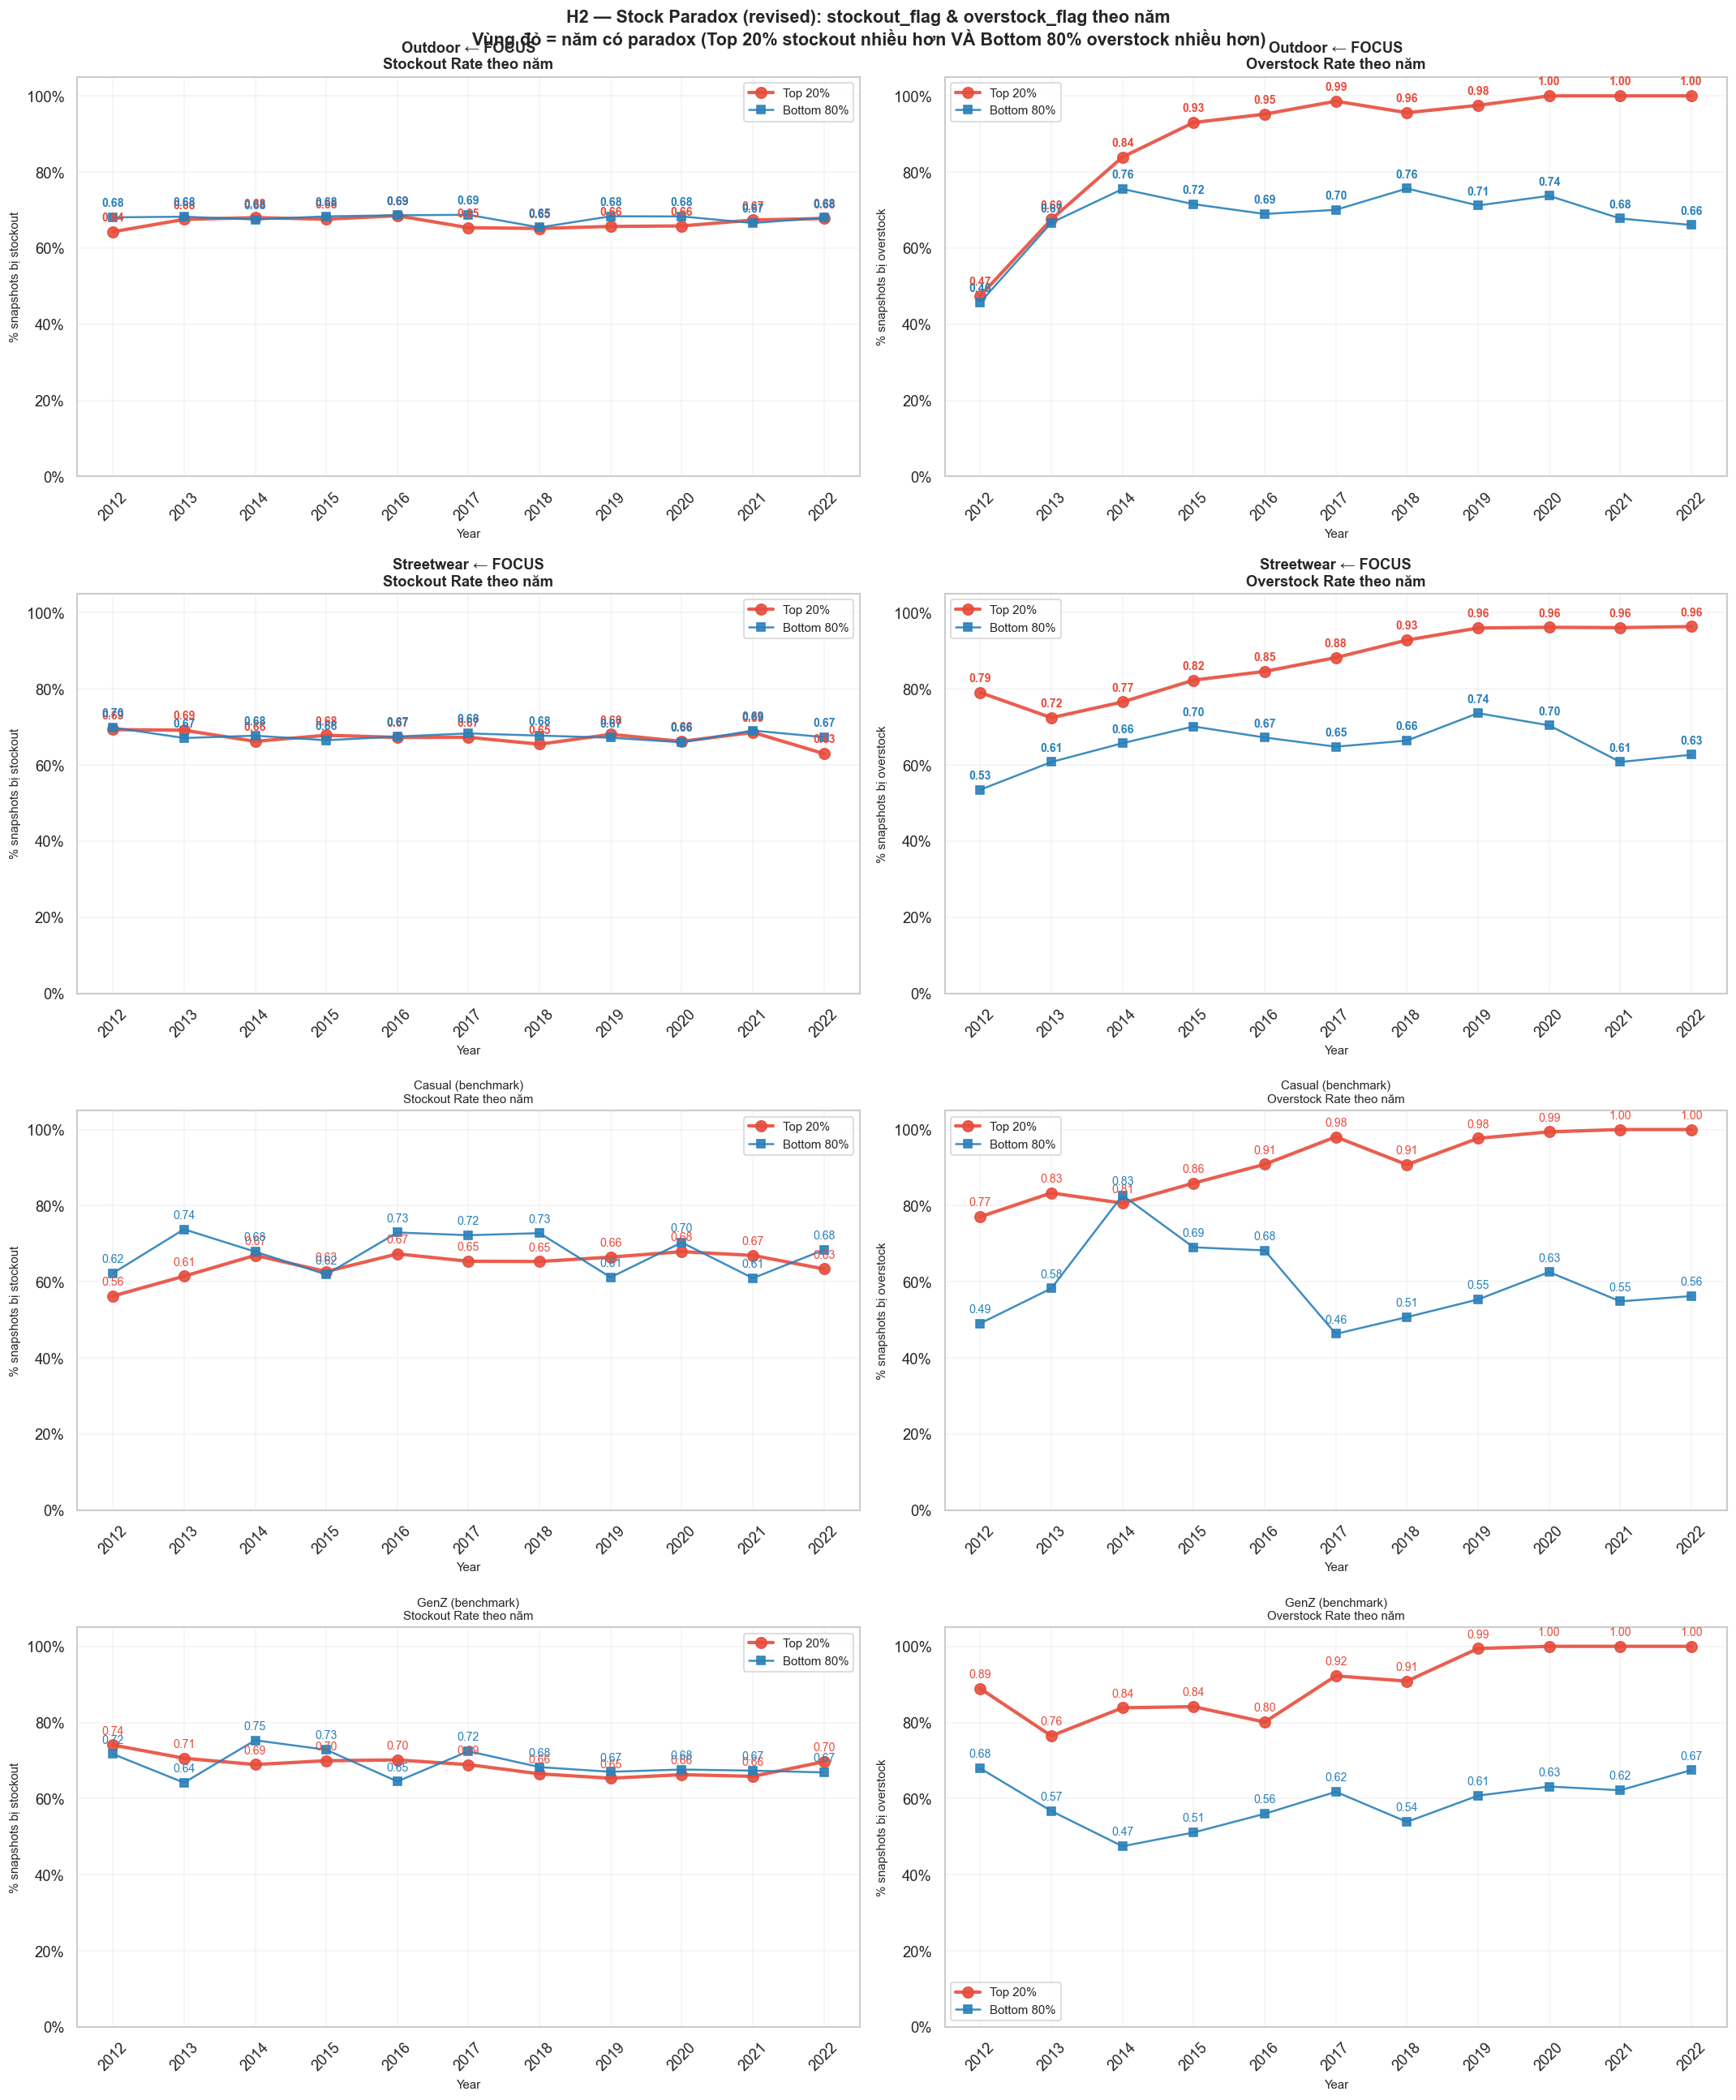

In [86]:
# Tính revenue trước
sales_lines['revenue'] = sales_lines['quantity'] * sales_lines['unit_price']

# H2 NEW — dùng thẳng inventory (đã có sku_tier, stockout_flag, overstock_flag)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# Kiểm tra sku_tier đã đủ chưa
print("sku_tier in inventory:", inventory['sku_tier'].unique())
print("Missing sku_tier:", inventory['sku_tier'].isna().sum())

# Nếu sku_tier toàn NaN thì rebuild
if inventory['sku_tier'].isna().all() or 'sku_tier' not in inventory.columns:
    sales_lines['revenue'] = sales_lines['quantity'] * sales_lines['unit_price']
    sku_rev = (
        sales_lines.groupby(['product_id', 'category'], as_index=False)
        .agg(total_revenue=('revenue', 'sum'))
    )
    sku_rev['sku_tier'] = 'Bottom 80%'
    for cat in sku_rev['category'].dropna().unique():
        mask = sku_rev['category'] == cat
        thresh = sku_rev.loc[mask, 'total_revenue'].quantile(0.8)
        sku_rev.loc[mask & (sku_rev['total_revenue'] >= thresh), 'sku_tier'] = 'Top 20%'
    inventory = inventory.drop(columns=['sku_tier'], errors='ignore')
    inventory = inventory.merge(sku_rev[['product_id', 'sku_tier']], on='product_id', how='left')

# Aggregate
paradox_yr = (
    inventory.groupby(['year', 'category', 'sku_tier'], as_index=False)
    .agg(
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        n_sku=('product_id', 'nunique')
    )
)

print(paradox_yr[paradox_yr['category'].isin(['Outdoor', 'Streetwear'])].to_string(index=False))

# Plot
TARGET = ['Outdoor', 'Streetwear']
BENCH  = ['Casual', 'GenZ']
ALL_CATS = TARGET + BENCH

fig, axes = plt.subplots(4, 2, figsize=(18, 22))

tier_styles = {
    'Top 20%':    {'color': '#E74C3C', 'marker': 'o', 'lw': 2.5, 'ms': 8},
    'Bottom 80%': {'color': '#2980B9', 'marker': 's', 'lw': 1.5, 'ms': 6},
}

for idx, cat in enumerate(ALL_CATS):
    d = paradox_yr[paradox_yr['category'] == cat].copy()
    is_focus = cat in TARGET
    ax_so = axes[idx][0]
    ax_os = axes[idx][1]

    if d.empty:
        ax_so.set_visible(False)
        ax_os.set_visible(False)
        continue

    all_years = sorted(d['year'].unique())

    for tier, style in tier_styles.items():
        sub = d[d['sku_tier'] == tier].sort_values('year')
        if sub.empty:
            continue
        for ax, col in [(ax_so, 'stockout_rate'), (ax_os, 'overstock_rate')]:
            ax.plot(sub['year'], sub[col],
                    color=style['color'], marker=style['marker'],
                    linewidth=style['lw'], markersize=style['ms'],
                    label=tier, alpha=0.9)
            for _, row in sub.iterrows():
                ax.annotate(f"{row[col]:.2f}",
                            (row['year'], row[col]),
                            textcoords='offset points', xytext=(0, 8),
                            ha='center', fontsize=8.5,
                            color=style['color'],
                            fontweight='bold' if is_focus else 'normal')

    # Highlight paradox year: top stockout > bottom stockout VÀ bottom overstock > top overstock
    so_med = paradox_yr['stockout_rate'].median()
    os_med = paradox_yr['overstock_rate'].median()
    for yr in all_years:
        yr_d = d[d['year'] == yr]
        top_so  = yr_d[yr_d['sku_tier'] == 'Top 20%']['stockout_rate'].values
        bot_so  = yr_d[yr_d['sku_tier'] == 'Bottom 80%']['stockout_rate'].values
        top_os  = yr_d[yr_d['sku_tier'] == 'Top 20%']['overstock_rate'].values
        bot_os  = yr_d[yr_d['sku_tier'] == 'Bottom 80%']['overstock_rate'].values
        is_paradox = (
            len(top_so) > 0 and len(bot_so) > 0 and
            len(top_os) > 0 and len(bot_os) > 0 and
            top_so[0] > bot_so[0] and  # top bị stockout nhiều hơn bottom
            bot_os[0] > top_os[0]       # bottom bị overstock nhiều hơn top
        )
        if is_paradox:
            ax_so.axvspan(yr - 0.4, yr + 0.4, alpha=0.12, color='red')
            ax_os.axvspan(yr - 0.4, yr + 0.4, alpha=0.12, color='red')

    fw = 'bold' if is_focus else 'normal'
    fs = 11 if is_focus else 9
    focus_label = '← FOCUS' if is_focus else '(benchmark)'

    ax_so.set_title(f'{cat} {focus_label}\nStockout Rate theo năm', fontweight=fw, fontsize=fs)
    ax_so.set_ylabel('% snapshots bị stockout', fontsize=9)
    ax_os.set_title(f'{cat} {focus_label}\nOverstock Rate theo năm', fontweight=fw, fontsize=fs)
    ax_os.set_ylabel('% snapshots bị overstock', fontsize=9)

    for ax in [ax_so, ax_os]:
        ax.set_xlabel('Year', fontsize=9)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_xticks(all_years)
        ax.set_xticklabels([str(int(y)) for y in all_years], rotation=45)
        ax.grid(True, alpha=0.2)

fig.suptitle(
    'H2 — Stock Paradox (revised): stockout_flag & overstock_flag theo năm\n'
    'Vùng đỏ = năm có paradox (Top 20% stockout nhiều hơn VÀ Bottom 80% overstock nhiều hơn)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [84]:

print(inventory.columns.tolist())
print(sales_lines.columns.tolist())

['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month', 'sku_tier']
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2', 'order_date', 'year', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']


Sample:
 year   category  units_received  units_sold  overstock_rate  stockout_rate  str_mean  str_agg
 2012    Outdoor           29680       25125        0.464431       0.665650  0.267133 0.846530
 2012 Streetwear           24302       20729        0.624350       0.696362  0.221767 0.852975
 2013    Outdoor           62842       53268        0.670761       0.679263  0.207950 0.847650
 2013 Streetwear           63797       54398        0.650469       0.678284  0.205969 0.852673
 2014    Outdoor           61547       52219        0.797565       0.677638  0.162936 0.848441
 2014 Streetwear           68714       58311        0.702135       0.670608  0.185820 0.848604
 2015    Outdoor           57667       48977        0.825056       0.679642  0.144615 0.849307
 2015 Streetwear           73797       62747        0.756570       0.670828  0.168434 0.850265
 2016    Outdoor           49925       42569        0.819868       0.685651  0.134566 0.852659
 2016 Streetwear           78657       666

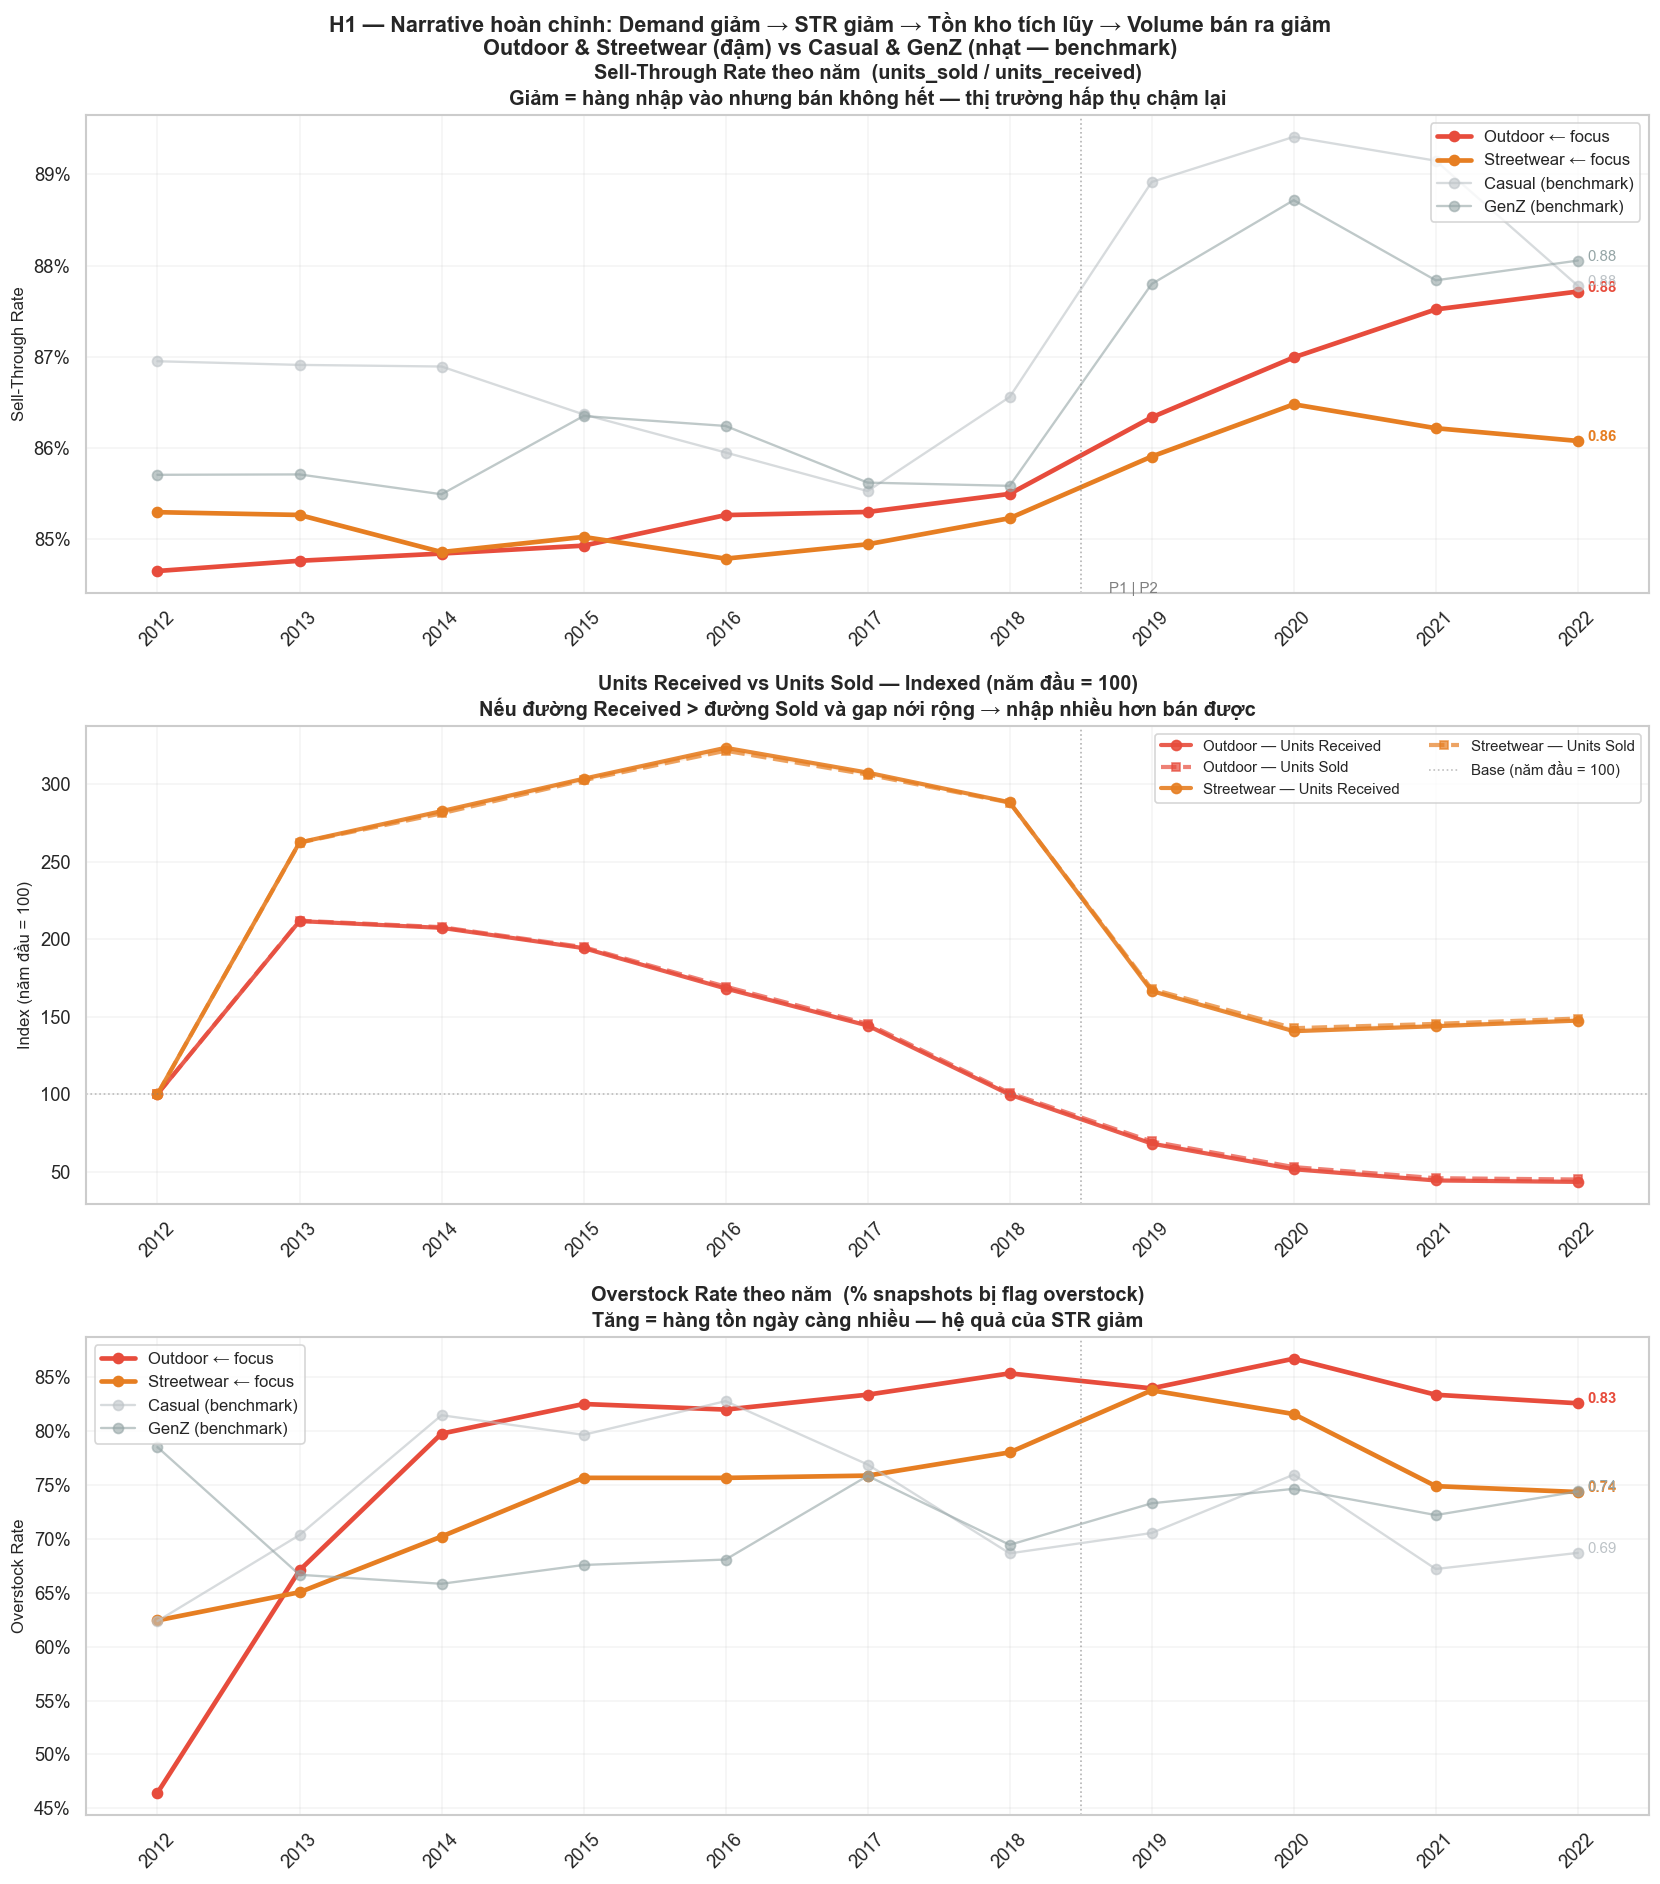

In [87]:
# H1 CONSOLIDATION: Narrative hoàn chỉnh
# Panel 1: Sell-Through Rate theo năm (units_sold / units_received)
# Panel 2: Units Received vs Units Sold tách biệt
# Panel 3: Overstock Rate trend (đã có) — để confirm hệ quả

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

TARGET = ['Outdoor', 'Streetwear']
BENCH  = ['Casual', 'GenZ']
ALL_CATS = TARGET + BENCH

CAT_COLORS = {
    'Outdoor':    '#E74C3C',
    'Streetwear': '#E67E22',
    'Casual':     '#BDC3C7',
    'GenZ':       '#95A5A6',
}
CAT_LW = {'Outdoor': 2.8, 'Streetwear': 2.8, 'Casual': 1.4, 'GenZ': 1.4}
CAT_ALPHA = {'Outdoor': 1.0, 'Streetwear': 1.0, 'Casual': 0.6, 'GenZ': 0.6}

# ── Aggregate từ inventory ──────────────────────────────────────────────────
inv_cat_yr = (
    inventory.groupby(['year', 'category'], as_index=False)
    .agg(
        units_received=('units_received', 'sum'),
        units_sold=('units_sold', 'sum'),
        overstock_rate=('overstock_flag', 'mean'),
        stockout_rate=('stockout_flag', 'mean'),
        str_mean=('sell_through_rate', 'mean'),   # backup nếu có sẵn
    )
)

# Tính STR từ aggregate (chính xác hơn mean of mean)
inv_cat_yr['str_agg'] = inv_cat_yr['units_sold'] / inv_cat_yr['units_received'].replace(0, np.nan)

print("Sample:")
print(inv_cat_yr[inv_cat_yr['category'].isin(TARGET)].to_string(index=False))

# ── Plot: 3 rows × 1 col, mỗi row 1 metric, tất cả category trên cùng 1 chart ──
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

years = sorted(inv_cat_yr['year'].unique())

# ── Panel 1: Sell-Through Rate ──────────────────────────────────────────────
ax1 = axes[0]
for cat in ALL_CATS:
    d = inv_cat_yr[inv_cat_yr['category'] == cat].sort_values('year')
    ax1.plot(d['year'], d['str_agg'],
             color=CAT_COLORS[cat], linewidth=CAT_LW[cat],
             alpha=CAT_ALPHA[cat], marker='o', markersize=6,
             label=cat + (' ← focus' if cat in TARGET else ' (benchmark)'))
    # Label điểm cuối
    last = d.iloc[-1]
    ax1.annotate(f"{last['str_agg']:.2f}",
                 (last['year'], last['str_agg']),
                 textcoords='offset points', xytext=(6, 0),
                 fontsize=9, color=CAT_COLORS[cat], fontweight='bold' if cat in TARGET else 'normal')

ax1.axvline(2018.5, color='gray', linestyle=':', lw=1, alpha=0.6)
ax1.text(2018.7, ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 0.3,
         'P1 | P2', fontsize=9, color='gray')
ax1.set_title('Sell-Through Rate theo năm  (units_sold / units_received)\n'
              'Giảm = hàng nhập vào nhưng bán không hết — thị trường hấp thụ chậm lại',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('Sell-Through Rate', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.2)
ax1.set_xticks(years)
ax1.set_xticklabels([str(int(y)) for y in years], rotation=45)

# ── Panel 2: Units Received vs Units Sold — chỉ Outdoor & Streetwear ───────
ax2 = axes[1]

# Normalize về index năm đầu = 100 để so sánh trajectory
for cat in TARGET:
    d = inv_cat_yr[inv_cat_yr['category'] == cat].sort_values('year').copy()
    base_recv = d['units_received'].iloc[0]
    base_sold = d['units_sold'].iloc[0]
    d['recv_idx'] = d['units_received'] / base_recv * 100
    d['sold_idx'] = d['units_sold'] / base_sold * 100

    ls_recv = '-'
    ls_sold = '--'
    color = CAT_COLORS[cat]

    ax2.plot(d['year'], d['recv_idx'],
             color=color, linewidth=2.5, linestyle=ls_recv,
             marker='o', markersize=6, alpha=0.9,
             label=f'{cat} — Units Received')
    ax2.plot(d['year'], d['sold_idx'],
             color=color, linewidth=2.5, linestyle=ls_sold,
             marker='s', markersize=5, alpha=0.7,
             label=f'{cat} — Units Sold')

    # Shade gap giữa received và sold
    ax2.fill_between(d['year'], d['recv_idx'], d['sold_idx'],
                     alpha=0.08, color=color)

ax2.axhline(100, color='gray', linestyle=':', lw=1, alpha=0.5, label='Base (năm đầu = 100)')
ax2.axvline(2018.5, color='gray', linestyle=':', lw=1, alpha=0.6)
ax2.set_title('Units Received vs Units Sold — Indexed (năm đầu = 100)\n'
              'Nếu đường Received > đường Sold và gap nới rộng → nhập nhiều hơn bán được',
              fontweight='bold', fontsize=12)
ax2.set_ylabel('Index (năm đầu = 100)', fontsize=10)
ax2.legend(fontsize=9, ncol=2)
ax2.grid(True, alpha=0.2)
ax2.set_xticks(years)
ax2.set_xticklabels([str(int(y)) for y in years], rotation=45)

# ── Panel 3: Overstock Rate — confirm hệ quả ───────────────────────────────
ax3 = axes[2]
for cat in ALL_CATS:
    d = inv_cat_yr[inv_cat_yr['category'] == cat].sort_values('year')
    ax3.plot(d['year'], d['overstock_rate'],
             color=CAT_COLORS[cat], linewidth=CAT_LW[cat],
             alpha=CAT_ALPHA[cat], marker='o', markersize=6,
             label=cat + (' ← focus' if cat in TARGET else ' (benchmark)'))
    last = d.iloc[-1]
    ax3.annotate(f"{last['overstock_rate']:.2f}",
                 (last['year'], last['overstock_rate']),
                 textcoords='offset points', xytext=(6, 0),
                 fontsize=9, color=CAT_COLORS[cat],
                 fontweight='bold' if cat in TARGET else 'normal')

ax3.axvline(2018.5, color='gray', linestyle=':', lw=1, alpha=0.6)
ax3.set_title('Overstock Rate theo năm  (% snapshots bị flag overstock)\n'
              'Tăng = hàng tồn ngày càng nhiều — hệ quả của STR giảm',
              fontweight='bold', fontsize=12)
ax3.set_ylabel('Overstock Rate', fontsize=10)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(True, alpha=0.2)
ax3.set_xticks(years)
ax3.set_xticklabels([str(int(y)) for y in years], rotation=45)

fig.suptitle(
    'H1 — Narrative hoàn chỉnh: Demand giảm → STR giảm → Tồn kho tích lũy → Volume bán ra giảm\n'
    'Outdoor & Streetwear (đậm) vs Casual & GenZ (nhạt — benchmark)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()